# **Modeling Urban Form Features to Analyze their Relationship with Pedestrian Counts**

Note that we did not specify a random seed when running the code for the paper.

**Outputs** (saved under `Output_data_from_modeling_scripts`):

Model pickle files
- CatBoost model
    - `orig_errors_vec_cat.pkl`
    - `cat_shap_values.pkl`
    - `cat_feature_analysis_error_arrs.pkl`
    - `cat_shap_values_report.pkl`
- LightGBM model
    - `orig_errors_vec_lgbm.pkl`
    - `lgbm_shap_values.pkl`
    - `lgbm_feature_analysis_error_arrs.pkl`
    - `lgb_shap_values_report.pkl`
- XGBoost model
    - `orig_errors_vec_xgb.pkl`
    - `xgb_shap_values.pkl`
    - `xgb_feature_analysis_error_arrs.pkl`
    - `xgb_shap_values_report.pkl`
- All models
    - `all_models.pkl`
    - `all_model_tests.pkl`

- Reproduced models for residual spatial autocorrelation check
    - `all_model_reproduced_with_location_id.pkl`
    - `location_id.pkl`
    - `all_model_tests_x_y_location_id.pkl`

csv file
- `feature_importance_values.csv`

Visualizations
- Summary of pedestrian data
- Mean absolute SHAP values bar charts
- Average pedestrian count plots by day type
- SHAP score rankings figures


**Start date:** *Aug 27, 2024*<br>
**Last update:** *Apr 9, 2026*<br>
**Authors:** *Benjamin Tarver & Kanaha Shoji*

In [ ]:
# Import necessary packages
# General use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import multiprocessing

# Scaling/sampling data
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# ML models
from catboost import Pool, CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Evaluating model performance
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error # root_mean_squared_error,
import shap
import os
import seaborn as sns
import random
import matplotlib.patches as patches
from matplotlib.patches import Patch

pd.options.mode.chained_assignment = None 

In [2]:
# Set random seed for reproducibility
RandomSeed = 123
# np.random.seed(RandomSeed)
random.seed(RandomSeed)

In [3]:
# Set base directory
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/urban-walkability-insights'
# Set directory for output from data pocessing for modeling scripts
processed_dir = os.path.join(base_dir,'Output_data_from_processing_scripts')
# Set directory for output data
output_dir = os.path.join(base_dir,'Output_data_from_modeling_scripts')

In [4]:
# Import processed feature data
processed_melbourne_data = pd.read_csv(os.path.join(processed_dir,'processed_melbourne_data_for_modeling.csv'))

In [5]:
processed_melbourne_data.columns

Index(['15_Tram_count', '15_Intersection_density', 'Building count',
       'Cloud_cover', 'Population_total', 'Youth', 'Betweenness centrality',
       'Day', 'Hour', 'Building view mean', '5_Edge_length_avg', 'Location_id',
       'Closeness centrality', 'Longitude', 'Total_precipitation',
       '5_Job_count', '5_Intersection_density', '5_Building_use_diversity',
       'Wind_speed', '15_Job_count', 'Road view mean', '5_Tram_count',
       '15_Bus_count', '5_Lamp_density', 'Pedestrian_count',
       '5_Total_transit_stop_count', 'Children', 'Year', '5_Bench_density',
       'Visual complexity mean', 'Temperature', '15_Dwelling_count',
       '5_Walkable_path_length', '5_Bus_count', '15_Green_area',
       '5_Green_area', 'Elderly', '5_Parking_total', 'Footprint mean', 'Month',
       '15_Total_transit_stop_count', '15_Building_use_diversity', 'Day_type',
       '15_Lamp_density', '15_Tree_density', '5_Dwelling_count',
       'Green view mean', 'Sky view mean', '15_Walkable_path_leng

In [6]:
original_data = processed_melbourne_data

In [7]:
# Replace the Location_ID values with randomized identifiers, 
# ensuring that each location still maintains a consistent, unique ID but without any inherent bias due to the numerical patterns.
# Generate a random number for each unique Location_ID
location_map = {location: np.random.randint(1, 10000) for location in processed_melbourne_data['Location_id'].unique()}
processed_melbourne_data['Location_id'] = processed_melbourne_data['Location_id'].map(location_map)

In [8]:
# Extract measurements relevant to each time frame
# Mornings = 7-10, lunches = 11-14, late afternoon = 15-18, evening = 19-22
# weekend/holiday = (special day == 1)
mornings = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 7) & (processed_melbourne_data['Hour'] <= 10) & (processed_melbourne_data['Day_type'].astype('bool') == False)]
lunches = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 11) & (processed_melbourne_data['Hour'] <= 14) & (processed_melbourne_data['Day_type'].astype('bool') == False)]
afternoons = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 15) & (processed_melbourne_data['Hour'] <= 18) & (processed_melbourne_data['Day_type'].astype('bool') == False)]
evenings = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 19) & (processed_melbourne_data['Hour'] <= 22) & (processed_melbourne_data['Day_type'].astype('bool') == False)]

mornings_special = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 7) & (processed_melbourne_data['Hour'] <= 10) & (processed_melbourne_data['Day_type'].astype('bool') == True)]
lunches_special = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 11) & (processed_melbourne_data['Hour'] <= 14) & (processed_melbourne_data['Day_type'].astype('bool') == True)]
afternoons_special = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 15) & (processed_melbourne_data['Hour'] <= 18) & (processed_melbourne_data['Day_type'].astype('bool') == True)]
evenings_special = processed_melbourne_data.loc[(processed_melbourne_data['Hour'] >= 19) & (processed_melbourne_data['Hour'] <= 22) & (processed_melbourne_data['Day_type'].astype('bool') == True)]

dfs = [mornings, lunches, afternoons, evenings, mornings_special, lunches_special, afternoons_special, evenings_special]
dfs = [df.groupby(['Year', 'Month', 'Day', 'Location_id']).mean(numeric_only=True).reset_index() for df in dfs]
dfs = [df.drop(columns=['Hour', 'Day_type']) for df in dfs]
dfs = [processed_melbourne_data] + dfs

df_names = ['All', 'Mornings', 'Lunches', 'Afternoons', 'Evenings', 'Mornings Special', 'Lunches Special', 'Afternoons Special', 'Evenings Special']

In [9]:
# For report - get aggregated statistics on dataset and sub-datasets
num_rows = []
mean_peds = []
med_peds = []
std_peds = []
for df in dfs:
    num_rows.append(len(df))
    mean_peds.append(int(np.mean(df['Pedestrian_count'])))
    med_peds.append(int(np.median(df['Pedestrian_count'])))
    std_peds.append(int(np.std(df['Pedestrian_count'])))
export_stats = pd.DataFrame({
    'Dataset': df_names,
    'Time of Day': ['00-23', '07-10', '11-14', '15-18', '19-22', '07-10', '11-14', '15-18', '19-22'],
    'No. of Records': num_rows,
    'Mean Peds': mean_peds,
    'Median Peds': med_peds,
    'S.D. Peds': std_peds
})
# export_stats.to_csv(os.path.join(base_dir,'Report Figures and Tables/dataset_stats.csv'),index=False)

In [41]:
# Add a 'Dataset' column to each df and combine them into a single DataFrame
wide_data = []
for df, name in zip(dfs, df_names):
    temp_df = df.copy()
    temp_df['Dataset'] = name  # Add the name of the dataset
    wide_data.append(temp_df)

# Concatenate all dataframes
wide_df = pd.concat(wide_data, ignore_index=True)

In [ ]:
# Aggregating the data
summary_df = wide_df.groupby('Dataset')['Pedestrian_count'].agg(
    Num_Records='count',
    Mean_Value='mean',
    Std_Dev='std'
).reset_index()

# Round mean and standard deviation
summary_df[['Mean_Value', 'Std_Dev']] = summary_df[['Mean_Value', 'Std_Dev']].astype(int)#.round(0)

# Ensure Dataset follows the order in df_names
summary_df['Dataset'] = pd.Categorical(summary_df['Dataset'], categories=df_names, ordered=True)
summary_df = summary_df.sort_values('Dataset').reset_index(drop=True)

print(summary_df)

              Dataset  Num_Records  Mean_Value  Std_Dev
0                 All      2437514         590      810
1            Mornings        69078         726      613
2             Lunches        69078        1117      918
3          Afternoons        69076        1224     1005
4            Evenings        69075         546      541
5    Mornings Special        31655         303      303
6     Lunches Special        31655         967      953
7  Afternoons Special        31655         968      952
8    Evenings Special        31655         561      618


In [14]:
# Split data into first (error evaluation) and second (feature importance extraction) halves
first_halves = []
second_halves = []

first_halves = []
second_halves = []

for df in dfs:
    # Specify the number of samples you want
    n_samples = int(len(df) / 2)

    # Create the StratifiedShuffleSplit object
    split = StratifiedShuffleSplit(test_size=n_samples, random_state=RandomSeed)

    # Perform the split ('Month' is what the data are stratified by)
    train_index, test_index = next(split.split(df, df['Month']))

    # Append the split halves to the respective lists
    first_half = df.iloc[test_index]
    second_half = df.iloc[train_index]

    # # Drop 'Location_ID' only after splitting
    # first_half = first_half.drop(columns=['Location_ID'], errors='ignore')
    # second_half = second_half.drop(columns=['Location_ID'], errors='ignore')

    first_halves.append(first_half)
    second_halves.append(second_half)

## CatBoost

In [ ]:
# First halves - calculate top features using SHAP scores
cat_shap_values_bar = []
cat_shap_values = []
orig_errors_vec_cat = []
cat_models = {}
cat_x_test = {}

for i, df in enumerate(first_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    print(f"Dataset: {dataset_name}")
    print(f"Row count: {len(df)}")

    y = df['Pedestrian_count']
    x = df.drop(columns='Pedestrian_count')   
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)

    # Spin up and run CatBoost model
    train_pool = Pool(x_train, y_train)
    test_pool = Pool(x_test)
    cat = CatBoostRegressor(random_state=RandomSeed, learning_rate=0.1, iterations=1000, silent=True)
    # Fit model to training data
    cat.fit(train_pool)
    
    # Store the trained model and test set
    cat_models[dataset_name] = cat
    cat_x_test[dataset_name] = x_test

    # Make model predictions using testing data
    y_pred_cat = cat.predict(test_pool)
    # Generate and print errors for use as benchmark against trained model with dropped features
    cat_errors = [mean_absolute_error(y_test, y_pred_cat), 
                  # root_mean_squared_error(y_test, y_pred_cat), 
                  np.sqrt(mean_squared_error(y_test, y_pred_cat)),
                  r2_score(y_test, y_pred_cat)]
    print(f"CatBoost MAE, RMSE, R² for {df_names[i]}: {cat_errors}")
    orig_errors_vec_cat.append(cat_errors)
    # Generate feature importance scores for model inputs
    catsplainer = shap.TreeExplainer(cat)
    cat_shap_values_bar.append(catsplainer)
    cat_shap_values.append(catsplainer.shap_values(x_test))

Dataset: All
Row count: 1218757
CatBoost MAE, RMSE, R² for All: [113.94820823436093, 214.20452617768402, 0.9300952030035144]
Dataset: Mornings
Row count: 34826
CatBoost MAE, RMSE, R² for Mornings: [51.059365252037665, 89.79419609505592, 0.9791099183581862]
Dataset: Lunches
Row count: 34826
CatBoost MAE, RMSE, R² for Lunches: [98.15893675867171, 160.66587951283526, 0.9695321244748277]
Dataset: Afternoons
Row count: 34825
CatBoost MAE, RMSE, R² for Afternoons: [116.3950538757734, 195.62542565815917, 0.9626833761644025]
Dataset: Evenings
Row count: 34824
CatBoost MAE, RMSE, R² for Evenings: [117.02966119900267, 197.00478574908485, 0.8632879537391154]
Dataset: Mornings Special
Row count: 15961
CatBoost MAE, RMSE, R² for Mornings Special: [63.40884447757538, 130.55830320488428, 0.7895835157603464]
Dataset: Lunches Special
Row count: 15961
CatBoost MAE, RMSE, R² for Lunches Special: [147.4287915050765, 254.23955303812994, 0.9275067834892627]
Dataset: Afternoons Special
Row count: 15961
CatBo

In [13]:
# Dump
with open(os.path.join(output_dir,'orig_errors_vec_cat.pkl'), 'wb') as f:
    pickle.dump(orig_errors_vec_cat, f)
with open(os.path.join(output_dir,'cat_shap_values.pkl'), 'wb') as f:
    pickle.dump(cat_shap_values, f)

In [11]:
# Open
with open(os.path.join(output_dir,'orig_errors_vec_cat.pkl'), 'rb') as f:
    orig_errors_vec_cat = pickle.load(f)
with open(os.path.join(output_dir,'cat_shap_values.pkl'), 'rb') as f:
    cat_shap_values = pickle.load(f)

In [12]:
# Define row and column names
row_names = ["MAE", "RMSE", "R2"]
column_names = ["All", "Mornings", "Lunches", "Afternoons", "Evenings",
                "Special Mornings", "Special Lunches", "Special Afternoons", "Special Evenings"]
df = pd.DataFrame(orig_errors_vec_cat, columns=row_names, index=column_names)

In [16]:
# Get error metrics for all datasets over all studied numbers of features included
maes = []
rmses = []
r2s = []
for top in range(1, 36): # 1 to 35 inclusive
    mae_iter = []
    rmse_iter = []
    r2_iter = []

    # Eliminate variables procedurally (eliminate all but "top" # of variables)
    top_keep = top
    # print(top)
    col_idx_keepers = []
    for vals in cat_shap_values:
        avg_abs_values = np.mean(np.abs(vals), axis=0)
        col_idx_keepers.append(np.argsort(avg_abs_values)[-top_keep:])

    for i, df in enumerate(second_halves):
        # Second halves - goal is to narrow features to feature set with very similar error to first half
        y = df['Pedestrian_count']
        x = df.drop(columns='Pedestrian_count')
        x = x.iloc[:, col_idx_keepers[i]] 
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)

        # Spin up and run CatBoost model
        train_pool = Pool(x_train, y_train)
        test_pool = Pool(x_test)
        cat = CatBoostRegressor(random_state=RandomSeed, learning_rate=0.1, iterations=1000, silent=True)
        # Fit model to training data
        cat.fit(train_pool)
        # Make model predictions using testing data
        y_pred_cat = cat.predict(test_pool)
        # Generate and print errors for use as benchmark against trained model with dropped features
        mae = mean_absolute_error(y_test, y_pred_cat)
        mae_iter.append(mae)
        # rmse = root_mean_squared_error(y_test, y_pred_cat)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
        rmse_iter.append(rmse)
        r2 = r2_score(y_test, y_pred_cat)
        r2_iter.append(r2)
        cat_errors = [mae, rmse, r2]
        # print(f"CatBoost MAE, RMSE, R² for {df_names[i]}: {cat_errors}")
    maes.append(mae_iter)
    rmses.append(rmse_iter)
    r2s.append(r2_iter)

In [17]:
# Dump
with open(os.path.join(output_dir,'cat_feature_analysis_error_arrs.pkl'), 'wb') as f:
    pickle.dump([maes, rmses, r2s], f)

In [18]:
# Open
with open(os.path.join(output_dir,'cat_feature_analysis_error_arrs.pkl'), 'rb') as f:
    errors_all_vec = pickle.load(f)

In [19]:
# Automate feature filtering process
mae_discrepancy = 0.05
rmse_discrepancy = 0.05
r2_discrepancy = 0.01
num_features_selected = []
maes_round2 = errors_all_vec[0][2:]
rmses_round2 = errors_all_vec[1][2:]
r2s_round2 = errors_all_vec[2][2:]

# The number of features selected is the number of features for which the MAE, RMSE, & R squared
# all fall into an acceptable error range, as defined by the above discrepancy values

missing_indices = []  # To track indices where no iteration passed the thresholds

for i in range(len(second_halves)):
    orig_mae = orig_errors_vec_cat[i][0]
    orig_rmse = orig_errors_vec_cat[i][1]
    orig_r2 = orig_errors_vec_cat[i][2]
    mae_iter = [x[i] for x in maes_round2]
    rmse_iter = [x[i] for x in rmses_round2]
    r2_iter = [x[i] for x in r2s_round2]
    passed = False  # To check if any iteration satisfies the conditions
    
    for j in range(len(mae_iter)):
        if (mae_iter[j] <= orig_mae * (1 + mae_discrepancy)) and \
           (rmse_iter[j] <= orig_rmse * (1 + rmse_discrepancy)) and \
           (r2_iter[j] >= orig_r2 * (1 - r2_discrepancy)):
            num_features_selected.append(j + 3)  # +3 because the first 3 features are preserved
            passed = True
            break
    
    if not passed:
        # No iteration passed, find the index with the largest R²
        max_r2_index = max(range(len(r2_iter)), key=lambda x: r2_iter[x])
        num_features_selected.append(max_r2_index + 3)  # +3 adjustment
        missing_indices.append(i)  # Log the index where thresholds were not met

# Print results
if missing_indices:
    print("No features passed the threshold for indices:", missing_indices)
    print("For these indices, the feature set with the largest R² was selected.")
else:
    print("All indices passed the threshold.")

No features passed the threshold for indices: [5]
For these indices, the feature set with the largest R² was selected.


In [20]:
cat_num_features_selected = num_features_selected

## LightGBM

In [21]:
# First halves - calculate top features using SHAP scores
lgbm_shap_values_bar = []
lgbm_shap_values = []
orig_errors_vec_lgbm = []
lgbm_models = {}
lgbm_x_test = {}

for i, df in enumerate(first_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    print(f"Dataset: {dataset_name}")
    print(f"Row count: {len(df)}")

    y = df['Pedestrian_count']
    x = df.drop(columns='Pedestrian_count')   
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)

    # Spin up and run CatBoost model
    lgbm= LGBMRegressor(n_jobs=multiprocessing.cpu_count() // 2, boosting_type='gbdt', learning_rate=.02, n_estimators=1000, random_state=RandomSeed)
    # Fit model to training data
    lgbm.fit(x_train, y_train)

    # Store the trained model and test set
    lgbm_models[dataset_name] = lgbm
    lgbm_x_test[dataset_name] = x_test
    
    # Make model predictions using testing data
    y_pred_lgbm = lgbm.predict(x_test)
    # Generate and print errors for use as benchmark against trained model with dropped features
    lgbm_errors = [mean_absolute_error(y_test, y_pred_lgbm), 
                #    root_mean_squared_error(y_test, y_pred_lgbm), 
                   np.sqrt(mean_squared_error(y_test, y_pred_lgbm)),
                   r2_score(y_test, y_pred_lgbm)]
    print(f"LGBM MAE, RMSE, R² for {df_names[i]}: {lgbm_errors}")
    orig_errors_vec_lgbm.append(lgbm_errors)
    # Generate feature importance scores for model inputs
    lightsplainer = shap.TreeExplainer(lgbm)
    lgbm_shap_values_bar.append(lightsplainer)
    lgbm_shap_values.append(lightsplainer.shap_values(x_test))

Dataset: All
Row count: 1218757
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3682
[LightGBM] [Info] Number of data points in the train set: 914067, number of used features: 50
[LightGBM] [Info] Start training from score 590.794150
LGBM MAE, RMSE, R² for All: [119.52777477226604, 222.566535554457, 0.9245308560857317]
Dataset: Mornings
Row count: 34826
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3788
[LightGBM] [Info] Number of data points in the train set: 26119, number of used f

In [22]:
# Dump
with open(os.path.join(output_dir,'orig_errors_vec_lgbm.pkl'), 'wb') as f:
    pickle.dump(orig_errors_vec_lgbm, f)
with open(os.path.join(output_dir,'lgbm_shap_values.pkl'), 'wb') as f:
    pickle.dump(lgbm_shap_values, f)

In [18]:
# Open
with open(os.path.join(output_dir,'orig_errors_vec_lgbm.pkl'), 'rb') as f:
    orig_errors_vec_lgbm = pickle.load(f)
with open(os.path.join(output_dir,'lgbm_shap_values.pkl'), 'rb') as f:
    lgbm_shap_values = pickle.load(f)

In [19]:
# Define row and column names
df = pd.DataFrame(orig_errors_vec_lgbm, columns=row_names, index=column_names)

In [23]:
# Get error metrics for all datasets over all studied numbers of features included
maes = []
rmses = []
r2s = []
for top in range(1, 36): # 5 to 35 inclusive
    mae_iter = []
    rmse_iter = []
    r2_iter = []

    # Eliminate variables procedurally (eliminate all but "top" # of variables)
    top_keep = top
    # print(top)
    col_idx_keepers = []
    for vals in lgbm_shap_values:
        avg_abs_values = np.mean(np.abs(vals), axis=0)
        col_idx_keepers.append(np.argsort(avg_abs_values)[-top_keep:])

    for i, df in enumerate(second_halves):
        # Second halves - goal is to narrow features to feature set with very similar error to first half
        lgbm_shap_values_final = []
        lgbm_shap_values_bar_final = []
        x_tests_s = []
        y = df['Pedestrian_count']
        x = df.drop(columns='Pedestrian_count')
        x = x.iloc[:, col_idx_keepers[i]] 
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)
        x_tests_s.append(x_test)

        # Spin up and run lgbmBoost model
        lgbm= LGBMRegressor(n_jobs=multiprocessing.cpu_count() // 2, boosting_type='gbdt', learning_rate=.02, n_estimators=1000, random_state=RandomSeed, verbose=-1)
        # Fit model to training data
        lgbm.fit(x_train,y_train)
        # Make model predictions using testing data
        y_pred_lgbm = lgbm.predict(x_test)
        # Generate and print errors for use as benchmark against trained model with dropped features
        mae = mean_absolute_error(y_test, y_pred_lgbm)
        mae_iter.append(mae)
        rmse= np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
        rmse_iter.append(rmse)
        r2 = r2_score(y_test, y_pred_lgbm)
        r2_iter.append(r2)
        lgbm_errors = [mae, rmse, r2]
        # print(f"LGBM MAE, RMSE, R² for {df_names[i]}: {lgbm_errors}")
        # # For error statistics that are satisfactory
        # lgbmsplainer = shap.TreeExplainer(lgbm)
        # lgbm_shap_values_bar_final.append(lgbmsplainer)
        # lgbm_shap_values_final.append(lgbmsplainer.shap_values(x_test))
    maes.append(mae_iter)
    rmses.append(rmse_iter)
    r2s.append(r2_iter)

In [26]:
# Dump
with open(os.path.join(output_dir,'lgbm_feature_analysis_error_arrs.pkl'), 'wb') as f:
    pickle.dump([maes, rmses, r2s], f)

In [27]:
# Open
with open(os.path.join(output_dir,'lgbm_feature_analysis_error_arrs.pkl'), 'rb') as f:
    errors_all_vec = pickle.load(f)

In [28]:
# Automate feature filtering process
mae_discrepancy = 0.05
rmse_discrepancy = 0.05
r2_discrepancy = 0.01
num_features_selected = []
maes_round2 = errors_all_vec[0][2:]
rmses_round2 = errors_all_vec[1][2:]
r2s_round2 = errors_all_vec[2][2:]

# The number of features selected is the number of features for which the MAE, RMSE, & R squared
# all fall into an acceptable error range, as defined by the above discrepancy values

missing_indices = []  # To track indices where no iteration passed the thresholds

for i in range(len(second_halves)):
    orig_mae = orig_errors_vec_lgbm[i][0]
    orig_rmse = orig_errors_vec_lgbm[i][1]
    orig_r2 = orig_errors_vec_lgbm[i][2]
    mae_iter = [x[i] for x in maes_round2]
    rmse_iter = [x[i] for x in rmses_round2]
    r2_iter = [x[i] for x in r2s_round2]
    passed = False  # To check if any iteration satisfies the conditions
    
    for j in range(len(mae_iter)):
        if (mae_iter[j] <= orig_mae * (1 + mae_discrepancy)) and \
           (rmse_iter[j] <= orig_rmse * (1 + rmse_discrepancy)) and \
           (r2_iter[j] >= orig_r2 * (1 - r2_discrepancy)):
            num_features_selected.append(j + 3)  # +3 because the first 3 features are preserved
            passed = True
            break
    
    if not passed:
        # No iteration passed, find the index with the largest R²
        max_r2_index = max(range(len(r2_iter)), key=lambda x: r2_iter[x])
        num_features_selected.append(max_r2_index + 3)  # +3 adjustment
        missing_indices.append(i)  # Log the index where thresholds were not met

# Print results
if missing_indices:
    print("No features passed the threshold for indices:", missing_indices)
    print("For these indices, the feature set with the largest R² was selected.")
else:
    print("All indices passed the threshold.")

No features passed the threshold for indices: [5]
For these indices, the feature set with the largest R² was selected.


In [29]:
lgbm_num_features_selected = num_features_selected

## XGBoost

In [30]:
# First halves - calculate top features using SHAP scores
xgb_shap_values_bar = []
xgb_shap_values = []
orig_errors_vec_xgb = []
xgb_models = {}
xgb_x_test = {}

for i, df in enumerate(first_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    print(f"Dataset: {dataset_name}")
    print(f"Row count: {len(df)}")

    y = df['Pedestrian_count']
    x = df.drop(columns='Pedestrian_count')   
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)

    # Spin up and run CatBoost model
    xgb=XGBRegressor(n_jobs=multiprocessing.cpu_count() // 2, tree_method="hist", max_depth=8, n_estimators=50, random_state=RandomSeed)
    # Fit model to training data
    xgb.fit(x_train, y_train) 

    # Store the trained model and test set
    xgb_models[dataset_name] = xgb
    xgb_x_test[dataset_name] = x_test

    # Make model predictions using testing data
    y_pred_xgb = xgb.predict(x_test)
    # Generate and print errors for use as benchmark against trained model with dropped features
    xgb_errors = [mean_absolute_error(y_test, y_pred_xgb), 
                #   root_mean_squared_error(y_test, y_pred_xgb), 
                  np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
                  r2_score(y_test, y_pred_xgb)]
    print(f"XGBoost MAE, RMSE, R² for {df_names[i]}: {xgb_errors}")
    orig_errors_vec_xgb.append(xgb_errors)
    # Generate feature importance scores for model inputs
    xsplainer = shap.TreeExplainer(xgb)
    xgb_shap_values_bar.append(xsplainer)
    xgb_shap_values.append(xsplainer.shap_values(x_test, check_additivity=False))

Dataset: All
Row count: 1218757
XGBoost MAE, RMSE, R² for All: [105.58301176706121, 202.51256177174972, 0.937518186352401]
Dataset: Mornings
Row count: 34826
XGBoost MAE, RMSE, R² for Mornings: [53.11300328883564, 94.52969327593112, 0.9768484484560204]
Dataset: Lunches
Row count: 34826
XGBoost MAE, RMSE, R² for Lunches: [101.84494656849444, 168.62850961653302, 0.9664373020621744]
Dataset: Afternoons
Row count: 34825
XGBoost MAE, RMSE, R² for Afternoons: [117.45855503224938, 200.65997973725732, 0.9607379227601788]
Dataset: Evenings
Row count: 34824
XGBoost MAE, RMSE, R² for Evenings: [116.89361254541238, 200.2687428836987, 0.8587203617214874]
Dataset: Mornings Special
Row count: 15961
XGBoost MAE, RMSE, R² for Mornings Special: [66.40544975454706, 147.01201162951375, 0.7332057863967352]
Dataset: Lunches Special
Row count: 15961
XGBoost MAE, RMSE, R² for Lunches Special: [151.19554718925642, 266.63030846020854, 0.9202684572934183]
Dataset: Afternoons Special
Row count: 15961
XGBoost MAE,

In [31]:
# Dump
with open(os.path.join(output_dir,'orig_errors_vec_xgb.pkl'), 'wb') as f:
    pickle.dump(orig_errors_vec_xgb, f)
with open(os.path.join(output_dir,'xgb_shap_values.pkl'), 'wb') as f:
    pickle.dump(xgb_shap_values, f)

In [32]:
# Open
with open(os.path.join(output_dir,'orig_errors_vec_xgb.pkl'), 'rb') as f:
    orig_errors_vec_xgb = pickle.load(f)
with open(os.path.join(output_dir,'xgb_shap_values.pkl'), 'rb') as f:
    xgb_shap_values = pickle.load(f)

In [33]:
# Define row and column names
df = pd.DataFrame(orig_errors_vec_xgb, columns=row_names, index=column_names)

In [ ]:
# Get error metrics for all datasets over all studied numbers of features included
maes = []
rmses = []
r2s = []
for top in range(1, 36): # 5 to 35 inclusive
    mae_iter = []
    rmse_iter = []
    r2_iter = []

    # Eliminate variables procedurally (eliminate all but "top" # of variables)
    top_keep = top
    # print(top)
    col_idx_keepers = []
    for vals in xgb_shap_values:
        avg_abs_values = np.mean(np.abs(vals), axis=0)
        col_idx_keepers.append(np.argsort(avg_abs_values)[-top_keep:])

    for i, df in enumerate(second_halves):
        # Second halves - goal is to narrow features to feature set with very similar error to first half
        xgb_shap_values_final = []
        xgb_shap_values_bar_final = []
        x_tests_s = []
        y = df['Pedestrian_count']
        x = df.drop(columns='Pedestrian_count')
        x = x.iloc[:, col_idx_keepers[i]] 
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)
        x_tests_s.append(x_test)

        # Spin up and run XGBoost model
        xgb=XGBRegressor(n_jobs=multiprocessing.cpu_count() // 2, tree_method="hist", max_depth=8, n_estimators=50, random_state=RandomSeed)
        # Fit model to training data
        xgb.fit(x_train,y_train)
        # Make model predictions using testing data
        y_pred_xgb = xgb.predict(x_test)
        # Generate and print errors for use as benchmark against trained model with dropped features
        mae = mean_absolute_error(y_test, y_pred_xgb)
        mae_iter.append(mae)
        # rmse = root_mean_squared_error(y_test, y_pred_xgb)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
        rmse_iter.append(rmse)
        r2 = r2_score(y_test, y_pred_xgb)
        r2_iter.append(r2)
        xgb_errors = [mae, rmse, r2]
        # print(f"XGBoost MAE, RMSE, R² for {df_names[i]}: {xgb_errors}")
        # # For error statistics that are satisfactory
        # xgbsplainer = shap.TreeExplainer(xgb)
        # xgb_shap_values_bar_final.append(xgbsplainer)
        # xgb_shap_values_final.append(xgbsplainer.shap_values(x_test))
    maes.append(mae_iter)
    rmses.append(rmse_iter)
    r2s.append(r2_iter)

In [35]:
# Dump
with open(os.path.join(output_dir,'xgb_feature_analysis_error_arrs.pkl'), 'wb') as f:
    pickle.dump([maes, rmses, r2s], f)

In [36]:
# Open
with open(os.path.join(output_dir,'xgb_feature_analysis_error_arrs.pkl'), 'rb') as f:
    errors_all_vec = pickle.load(f)

In [37]:
# Automate feature filtering process
mae_discrepancy = 0.05
rmse_discrepancy = 0.05
r2_discrepancy = 0.01
num_features_selected = []
maes_round2 = errors_all_vec[0][2:]
rmses_round2 = errors_all_vec[1][2:]
r2s_round2 = errors_all_vec[2][2:]

# The number of features selected is the number of features for which the MAE, RMSE, & R squared
# all fall into an acceptable error range, as defined by the above discrepancy values

missing_indices = []  # To track indices where no iteration passed the thresholds

for i in range(len(second_halves)):
    orig_mae = orig_errors_vec_xgb[i][0]
    orig_rmse = orig_errors_vec_xgb[i][1]
    orig_r2 = orig_errors_vec_xgb[i][2]
    mae_iter = [x[i] for x in maes_round2]
    rmse_iter = [x[i] for x in rmses_round2]
    r2_iter = [x[i] for x in r2s_round2]
    passed = False  # To check if any iteration satisfies the conditions
    
    for j in range(len(mae_iter)):
        if (mae_iter[j] <= orig_mae * (1 + mae_discrepancy)) and \
           (rmse_iter[j] <= orig_rmse * (1 + rmse_discrepancy)) and \
           (r2_iter[j] >= orig_r2 * (1 - r2_discrepancy)):
            num_features_selected.append(j + 3)  # +3 because the first 3 features are preserved
            passed = True
            break
    
    if not passed:
        # No iteration passed, find the index with the largest R²
        max_r2_index = max(range(len(r2_iter)), key=lambda x: r2_iter[x])
        num_features_selected.append(max_r2_index + 3)  # +3 adjustment
        missing_indices.append(i)  # Log the index where thresholds were not met

# Print results
if missing_indices:
    print("No features passed the threshold for indices:", missing_indices)
    print("For these indices, the feature set with the largest R² was selected.")
else:
    print("All indices passed the threshold.")

All indices passed the threshold.


In [38]:
xgb_num_features_selected = num_features_selected

#### Baseline errors averaged across the selected models

In [39]:
# Open
with open(os.path.join(output_dir,'orig_errors_vec_cat.pkl'), 'rb') as f:
    orig_errors_vec_cat = pickle.load(f)
with open(os.path.join(output_dir,'orig_errors_vec_lgbm.pkl'), 'rb') as f:
    orig_errors_vec_lgb = pickle.load(f)
with open(os.path.join(output_dir,'orig_errors_vec_xgb.pkl'), 'rb') as f:
    orig_errors_vec_xgb = pickle.load(f)

In [40]:
df = pd.DataFrame(orig_errors_vec_lgbm, columns=row_names, index=column_names)
print('LGBM')
print(df)

LGBM
                           MAE        RMSE        R2
All                 119.527775  222.566536  0.924531
Mornings             53.610686   96.378422  0.975934
Lunches             103.725055  170.447790  0.965709
Afternoons          121.418544  204.731422  0.959128
Evenings            119.361353  203.022887  0.854808
Special Mornings     62.656349  130.418441  0.790034
Special Lunches     144.153112  252.876664  0.928282
Special Afternoons  143.894494  248.620215  0.930361
Special Evenings    140.370482  247.301173  0.829858


In [41]:
df = pd.DataFrame(orig_errors_vec_xgb, columns=row_names, index=column_names)
print('XGB')
print(df)

XGB
                           MAE        RMSE        R2
All                 105.583012  202.512562  0.937518
Mornings             53.113003   94.529693  0.976848
Lunches             101.844947  168.628510  0.966437
Afternoons          117.458555  200.659980  0.960738
Evenings            116.893613  200.268743  0.858720
Special Mornings     66.405450  147.012012  0.733206
Special Lunches     151.195547  266.630308  0.920268
Special Afternoons  148.428792  259.554838  0.924101
Special Evenings    150.049774  274.601417  0.790220


In [42]:
df = pd.DataFrame(orig_errors_vec_cat, columns=row_names, index=column_names)
print('CatBoost')
print(df)

CatBoost
                           MAE        RMSE        R2
All                 113.948208  214.204526  0.930095
Mornings             51.059365   89.794196  0.979110
Lunches              98.158937  160.665880  0.969532
Afternoons          116.395054  195.625426  0.962683
Evenings            117.029661  197.004786  0.863288
Special Mornings     63.408844  130.558303  0.789584
Special Lunches     147.428792  254.239553  0.927507
Special Afternoons  144.387374  245.675470  0.932001
Special Evenings    145.020984  249.421219  0.826929


In [ ]:
# Ensure these are NumPy arrays for easier manipulation
orig_errors_vec_cat = np.array(orig_errors_vec_cat)
orig_errors_vec_lgb = np.array(orig_errors_vec_lgb)
orig_errors_vec_xgb = np.array(orig_errors_vec_xgb)

# Calculate average metrics
average_errors = (orig_errors_vec_cat + orig_errors_vec_lgb + orig_errors_vec_xgb) / 3

# Convert to DataFrame
df = pd.DataFrame(average_errors, columns=row_names, index=column_names)

# Print the resulting DataFrame
print("Averaged Errors (MAE, RMSE, R2):")
print(df)
# df.to_csv(os.path.join(output_dir,'averaged_errors.csv'))

Averaged Errors (MAE, RMSE, R2):
                           MAE        RMSE        R2
All                 113.019665  213.094541  0.930715
Mornings             52.594351   93.567437  0.977297
Lunches             101.242979  166.580726  0.967226
Afternoons          118.424051  200.338943  0.960850
Evenings            117.761542  200.098805  0.858939
Special Mornings     64.156881  135.996252  0.770941
Special Lunches     147.592484  257.915508  0.925352
Special Afternoons  145.570220  251.283508  0.928821
Special Evenings    145.147080  257.107936  0.815669


## SHAP chart

#### CatBoost

In [ ]:
best_cat = {}
best_cat_x_test = {}
best_cat_y_test = {}
best_cat_location_ids = {}
# Eliminate variables procedurally (eliminate all but top X # of variables)
col_idx_keepers = []
for i, vals in enumerate(cat_shap_values):
    avg_abs_values = np.mean(np.abs(vals), axis=0)
    col_idx_keepers.append(np.argsort(avg_abs_values)[-cat_num_features_selected[i]:])

# Second halves - goal is to narrow features to feature set with very similar error to first half
cat_shap_values_report = []
cat_shap_values_bar_report = []
x_tests_cat = []
for i, df in enumerate(second_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    df.columns = df.columns.str.replace('_', ' ', regex=True)
    df.columns = df.columns.str.replace('location id', 'location ID', regex=True)
    y = df['Pedestrian count']
    x = df.drop(columns='Pedestrian count')
    x = x.iloc[:, col_idx_keepers[i]] 
    location_ids = df['Location id'] # Retain for later use
    x_train, x_test, y_train, y_test,loc_train, loc_test = train_test_split(x, y, location_ids, test_size=0.25, random_state=RandomSeed)
    x_tests_cat.append(x_test)

    # Spin up and run CatBoost model
    train_pool = Pool(x_train, y_train)
    test_pool = Pool(x_test)
    cat = CatBoostRegressor(random_state=RandomSeed, learning_rate=0.1, iterations=1000, silent=True)
    # Fit model to training data
    cat.fit(train_pool)
    # Store the train model
    best_cat[dataset_name] = cat
    best_cat_x_test[dataset_name] = x_test
    best_cat_y_test[dataset_name] = y_test
    best_cat_location_ids[dataset_name] = loc_test
    
    # Make model predictions using testing data
    y_pred_cat = cat.predict(test_pool)
    # Generate and print errors for use as benchmark against trained model with dropped features
    # cat_errors = [mean_absolute_error(y_test, y_pred_cat), root_mean_squared_error(y_test, y_pred_cat), r2_score(y_test, y_pred_cat)]
    # print(f"CatBoost MAE, RMSE, R² for {df_names[i]}: {cat_errors}")
    # Uncomment once error statistics are satisfactory
    catsplainer = shap.TreeExplainer(cat)
    cat_shap_values_bar_report.append(catsplainer)
    catsplainer_ext = catsplainer.shap_values(x_test)
    cat_shap_values_report.append(catsplainer_ext)

In [45]:
# Dump
with open(os.path.join(output_dir,'cat_shap_values_report.pkl'), 'wb') as f:
    pickle.dump(cat_shap_values_report,f)

In [46]:
# Open
with open(os.path.join(output_dir,'cat_shap_values_report.pkl'), 'rb') as f:
    cat_shap_values_report = pickle.load(f)

#### LightGBM

In [ ]:
# Eliminate variables procedurally (eliminate all but top X # of variables)
lgb_shap_values_bar_report = []
lgb_shap_values_report = []
col_idx_keepers = []
x_tests_lgbm = []

best_lgb = {}
best_lgb_x_test = {}
best_lgb_y_test = {}
best_lgb_location_ids = {}

for i, vals in enumerate(lgbm_shap_values):
    avg_abs_values = np.mean(np.abs(vals), axis=0)
    col_idx_keepers.append(np.argsort(avg_abs_values)[-lgbm_num_features_selected[i]:])

for i, df in enumerate(second_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    df.columns = df.columns.str.replace('_', ' ', regex=True)
    df.columns = df.columns.str.replace('location id', 'location ID', regex=True)
    y = df['Pedestrian count']
    x = df.drop(columns='Pedestrian count')
    x = x.iloc[:, col_idx_keepers[i]]
    location_ids = df['Location id'] # Retain for later use  
    x_train, x_test, y_train, y_test,loc_train, loc_test = train_test_split(x, y, location_ids, test_size=0.25, random_state=RandomSeed)
    x_tests_lgbm.append(x_test)

    # Spin up and run lgbmBoost model
    lgb= LGBMRegressor(n_jobs=multiprocessing.cpu_count() // 2, boosting_type='gbdt', learning_rate=.02, n_estimators=1000, random_state=RandomSeed)
    # Fit model to training data
    lgb.fit(x_train, y_train)
    # Store the train model
    best_lgb[dataset_name] = lgb
    best_lgb_x_test[dataset_name] = x_test
    best_lgb_y_test[dataset_name] = y_test
    best_lgb_location_ids[dataset_name] = loc_test
    # Make model predictions using testing data
    y_pred = lgb.predict(x_test)
    # Generate and print errors for use as benchmark against trained model with dropped features
    # lgbm_errors = [mean_absolute_error(y_test, y_pred_lgbm), root_mean_squared_error(y_test, y_pred_lgbm), r2_score(y_test, y_pred_lgbm)]
    # print(f"lgbmBoost MAE, RMSE, R² for {df_names[i]}: {lgbm_errors}")
    lightsplainer = shap.TreeExplainer(lgb)
    lgb_shap_values_bar_report.append(lightsplainer)
    # shap.plots.bar(lightsplainer(x_test), max_display=40)
    lightsplainer_ext = lightsplainer.shap_values(x_test, check_additivity=False)
    lgb_shap_values_report.append(lightsplainer_ext)

In [48]:
# Dump
with open(os.path.join(output_dir,'lgb_shap_values_report.pkl'), 'wb') as f:
    pickle.dump(lgb_shap_values_report,f)

In [49]:
# Open
with open(os.path.join(output_dir,'lgb_shap_values_report.pkl'), 'rb') as f:
    lgb_shap_values_report = pickle.load(f)

#### XGBoost

In [ ]:
# Eliminate variables procedurally (eliminate all but top X # of variables)
xgb_shap_values_bar_report = []
xgb_shap_values_report = []
col_idx_keepers = []
x_tests_xgb = []

best_xgb = {}
best_xgb_x_test = {}
best_xgb_y_test = {}
best_xgb_location_ids = {}

for i, vals in enumerate(xgb_shap_values):
    avg_abs_values = np.mean(np.abs(vals), axis=0)
    col_idx_keepers.append(np.argsort(avg_abs_values)[-xgb_num_features_selected[i]:])

for i, df in enumerate(second_halves):
    dataset_name = df_names[i]  # Use dataset names from the first script
    df.columns = df.columns.str.replace('_', ' ', regex=True)
    df.columns = df.columns.str.replace('location id', 'location ID', regex=True)
    y = df['Pedestrian count']
    x = df.drop(columns='Pedestrian count')
    x = x.iloc[:, col_idx_keepers[i]] 
    location_ids = df['Location id'] # Retain for later use
    x_train, x_test, y_train, y_test,loc_train, loc_test = train_test_split(x, y, location_ids,test_size=0.25, random_state=RandomSeed)
    x_tests_xgb.append(x_test)

    # Spin up and run xgbBoost model
    xgb=XGBRegressor(n_jobs=multiprocessing.cpu_count() // 2, tree_method="hist", max_depth=8, n_estimators=50, random_state=RandomSeed)
    # Fit model to training data
    xgb.fit(x_train, y_train)
    # Store the train model
    best_xgb[dataset_name] = xgb
    best_xgb_x_test[dataset_name] = x_test
    best_xgb_y_test[dataset_name] = y_test
    best_xgb_location_ids[dataset_name] = loc_test
    # Make model predictions using testing data
    y_pred = xgb.predict(x_test)
    # Generate and print errors for use as benchmark against trained model with dropped features
    # xgb_errors = [mean_absolute_error(y_test, y_pred_xgb), root_mean_squared_error(y_test, y_pred_xgb), r2_score(y_test, y_pred_xgb)]
    # print(f"xgbBoost MAE, RMSE, R² for {df_names[i]}: {xgb_errors}")
    xsplainer = shap.TreeExplainer(xgb)
    xgb_shap_values_bar_report.append(xsplainer)
    # shap.plots.bar(xsplainer(x_test, check_additivity=False), max_display=40)
    xsplainer_ext = xsplainer.shap_values(x_test, check_additivity=False)
    xgb_shap_values_report.append(xsplainer_ext)

In [ ]:
# Dump
with open(os.path.join(output_dir,'xgb_shap_values_report.pkl'), 'wb') as f:
    pickle.dump(xgb_shap_values_report,f)

In [52]:
# Open
with open(os.path.join(output_dir,'xgb_shap_values_report.pkl'), 'rb') as f:
    xgb_shap_values_report = pickle.load(f)

In [ ]:
# Dump all dictionaries to a single pickle file
with open(os.path.join(output_dir,'all_models.pkl'), 'wb') as f:
    pickle.dump({"lgb_models": best_lgb, "cat_models": best_cat, "xgb_models": best_xgb}, f)

In [ ]:
# Dump all dictionaries to a single pickle file
with open(os.path.join(output_dir,'all_model_tests.pkl'), 'wb') as f:
    pickle.dump({"lgb_x_test": best_lgb_x_test, "cat_x_test": best_cat_x_test, "xgb_x_test": best_xgb_x_test}, f)

In [ ]:
# Dump all dictionaries to a single pickle file (recomputed with locaiton id tracked)
with open(os.path.join(output_dir,'all_models_reproduced_w_location_id.pkl'), 'wb') as f:
    pickle.dump({"lgb_models": best_lgb, "cat_models": best_cat, "xgb_models": best_xgb}, f)

In [ ]:
# Dump all test sets (recomputed with location IDs tracked)
with open(os.path.join(output_dir, 'all_model_tests_x_y_location_id.pkl'), 'wb') as f:
    pickle.dump(
        {   "lgb_x_test": best_lgb_x_test,
            "cat_x_test": best_cat_x_test,
            "xgb_x_test": best_xgb_x_test,
            "lgb_y_test": best_lgb_y_test,   
            "cat_y_test": best_cat_y_test,
            "xgb_y_test": best_xgb_y_test},f)

In [ ]:
# Dump all location IDs (recomputed with locaiton id tracked)
with open(os.path.join(output_dir, 'location_id.pkl'), 'wb') as f:
    pickle.dump(
        {   "lgb": best_lgb_location_ids,
            "cat": best_cat_location_ids,
            "xgb": best_xgb_location_ids},f)

In [ ]:
# Dump location_map for reference (recomputed with locaiton id tracked)
with open(os.path.join(output_dir,'location_map.pkl'), 'wb') as f:
    pickle.dump(location_map, f)

## Feature importance bar charts

In [5]:
# Load dictionaries from a single pickle file
with open(os.path.join(output_dir,'cat_shap_values_report.pkl'), 'rb') as f:
    cat_shap_values_report = pickle.load(f)
with open(os.path.join(output_dir,'xgb_shap_values_report.pkl'), 'rb') as f:
    xgb_shap_values_report = pickle.load(f)    
with open(os.path.join(output_dir,'lgb_shap_values_report.pkl'), 'rb') as f:
    lgb_shap_values_report = pickle.load(f)

In [6]:
# Load the dictionaries from the pickle file
with open(os.path.join(output_dir,'all_model_tests.pkl'), 'rb') as f:
    data = pickle.load(f)

# Access individual dictionaries
x_tests_lgbm = data["lgb_x_test"]
x_tests_cat = data["cat_x_test"]
x_tests_xgb = data["xgb_x_test"]

In [ ]:
# Initialize a list to store DataFrames for all subsets
all_importance_dataframes = []

for i in range(len(second_halves)):
    # Process CatBoost SHAP values
    dataset_name = df_names[i]
    # x_tests_cat[i].columns = x_tests_cat[i].columns.str.replace('location id', 'location ID', regex=True)
    cat_feature_names = x_tests_cat[dataset_name].columns
    cat_shap_vals_df = pd.DataFrame(cat_shap_values_report[i], columns=cat_feature_names)
    cat_vals = np.abs(cat_shap_vals_df.values).mean(0)
    cat_shap_importance = pd.DataFrame(list(zip(cat_feature_names, cat_vals)), columns=['col_name', 'importance_vals_cat'])
    cat_shap_importance.sort_values(by='importance_vals_cat', ascending=False, inplace=True)

    # Process LightGBM SHAP values
    # x_tests_lgbm[i].columns = x_tests_lgbm[i].columns.str.replace('location id', 'location ID', regex=True)
    lgbm_feature_names = x_tests_lgbm[dataset_name].columns
    lgbm_shap_vals_df = pd.DataFrame(lgb_shap_values_report[i], columns=lgbm_feature_names)
    lgbm_vals = np.abs(lgbm_shap_vals_df.values).mean(0)
    lgbm_shap_importance = pd.DataFrame(list(zip(lgbm_feature_names, lgbm_vals)), columns=['col_name', 'importance_vals_lgbm'])
    lgbm_shap_importance.sort_values(by='importance_vals_lgbm', ascending=False, inplace=True)

    # Process XGBoost SHAP values
    # x_tests_xgb[i].columns = x_tests_xgb[i].columns.str.replace('location id', 'location ID', regex=True)
    xgb_feature_names = x_tests_xgb[dataset_name].columns
    xgb_shap_vals_df = pd.DataFrame(xgb_shap_values_report[i], columns=xgb_feature_names)
    xgb_vals = np.abs(xgb_shap_vals_df.values).mean(0)
    xgb_shap_importance = pd.DataFrame(list(zip(xgb_feature_names, xgb_vals)), columns=['col_name', 'importance_vals_xgb'])
    xgb_shap_importance.sort_values(by='importance_vals_xgb', ascending=False, inplace=True)

    # Merge feature importance values from all models
    merged_shap_importance = (
        pd.merge(cat_shap_importance, lgbm_shap_importance, on='col_name', how='outer', suffixes=('_cat', '_lgbm'))
        .merge(xgb_shap_importance, on='col_name', how='outer')
        .fillna(0)
    )
    merged_shap_importance['sum_cols'] = (
        merged_shap_importance['importance_vals_cat'] +
        merged_shap_importance['importance_vals_lgbm'] +
        merged_shap_importance['importance_vals_xgb']
    )
    
    # Add dataset name column
    merged_shap_importance['dataset_name'] = df_names[i]
    
    # Data cleaning and formatting
    merged_shap_importance['col_name'] = merged_shap_importance['col_name'].replace('_', ' ', regex=True).str.lower()
    
    # Save to list
    all_importance_dataframes.append(merged_shap_importance)

# Combine all DataFrames into one for export or analysis
combined_importance_df = pd.concat(all_importance_dataframes, ignore_index=True)
combined_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_values.csv'), index=False)

In [8]:
combined_importance_df = pd.read_csv(os.path.join(output_dir,'feature_importance_values.csv'))

In [9]:
combined_importance_df['col_name'] = combined_importance_df['col_name'].replace({'special day': 'Day type'})


In [10]:
combined_importance_df_cap = combined_importance_df.copy()
# combined_importance_df_cap['col_name'] = combined_importance_df_cap['col_name'].str.title() # Capitalize first letter of each word
combined_importance_df_cap['col_name'] = combined_importance_df_cap['col_name'].str.replace(
    r'^(\s*\d*\s*)([a-zA-Z])', 
    lambda match: match.group(1) + match.group(2).upper(),
    regex=True
)
combined_importance_df_cap['col_name'] = combined_importance_df_cap['col_name'].replace({'Location id': 'Location ID'})

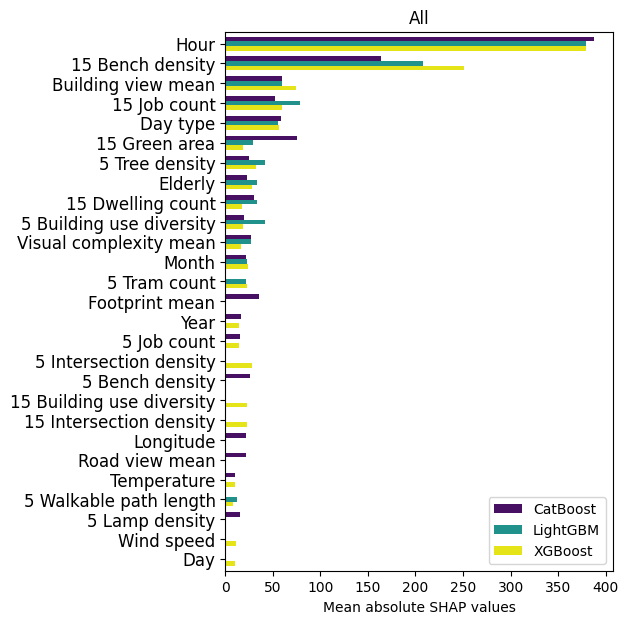

In [29]:
dataset_name = 'All'
# Filter the dataframe for the current dataset
df_filtered = combined_importance_df_cap[combined_importance_df_cap['dataset_name'] == dataset_name]

# Calculate the sum of importance values across all three models for each feature
df_filtered['sum_importance'] = (
    df_filtered['importance_vals_cat'] + 
    df_filtered['importance_vals_lgbm'] + 
    df_filtered['importance_vals_xgb']
)

# Sort the dataframe by the summed importance values in descending order
df_filtered = df_filtered.sort_values('sum_importance', ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(5, 7))
bars = df_filtered.plot(
    kind='barh',
    x='col_name',
    y=['importance_vals_cat', 'importance_vals_lgbm', 'importance_vals_xgb'],
    color=plt.cm.viridis([0.04, 0.5, 0.96], ), #alpha=0.4), 
    ax=ax,
    width=0.7
)

# Add labels and title
ax.set_xlabel('Mean absolute SHAP values', fontsize=10)
ax.set_ylabel(None)
ax.set_yticklabels(df_filtered['col_name'], fontsize=12)
ax.invert_yaxis()
ax.legend(['CatBoost', 'LightGBM', 'XGBoost'], fontsize=10)
ax.set_title(f'{dataset_name}', fontsize=12)

# Remove the background
plt.gcf().patch.set_alpha(0)  # Makes the figure background transparent
ax.set_facecolor('none')  # Ensures the axis background is also transparent
plt.show()


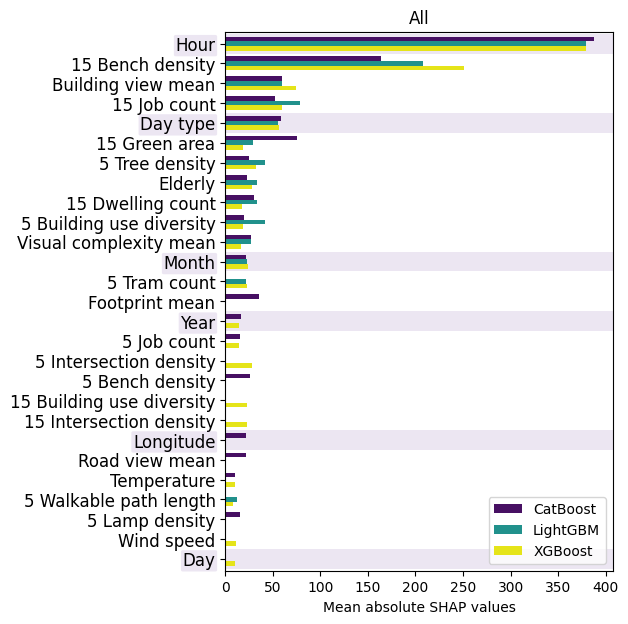

In [43]:
highlight_features = ["Hour", "Day type", "Month", "Year", "Longitude", "Day"]

# Create the plot
fig, ax = plt.subplots(figsize=(5, 7))
bars = df_filtered.plot(
    kind='barh',
    x='col_name',
    y=['importance_vals_cat', 'importance_vals_lgbm', 'importance_vals_xgb'],
    color=plt.cm.viridis([0.04, 0.5, 0.96]),
    ax=ax,
    width=0.7
)

# Original colors
colors = plt.cm.viridis([0.04, 0.5, 0.96])

legend_handles = [
    Patch(facecolor=colors[0], label='CatBoost'),
    Patch(facecolor=colors[1], label='LightGBM'),
    Patch(facecolor=colors[2], label='XGBoost')
]

ax.legend(handles=legend_handles, fontsize=10)
# Highlight selected rows with a purple background band
for i, feature in enumerate(df_filtered['col_name']):
    if feature in highlight_features:
        ax.axhspan(i - 0.5, i + 0.5, color='rebeccapurple', alpha=0.12,linewidth=0, zorder=0, )

# Add labels and title
ax.set_xlabel('Mean absolute SHAP values', fontsize=10)
ax.set_ylabel(None)
ax.set_yticklabels(df_filtered['col_name'], fontsize=12)
ax.invert_yaxis()
# ax.legend(['CatBoost', 'LightGBM', 'XGBoost'], fontsize=10)

for label in ax.get_yticklabels():
    if label.get_text() in highlight_features:
        label.set_bbox(dict(
            facecolor='rebeccapurple',
            alpha=0.12,
            edgecolor='none',
            boxstyle='round,pad=0.1'  # optional styling
        ))

ax.set_title(f'{dataset_name}', fontsize=12)

# Remove the background
plt.gcf().patch.set_alpha(0)
ax.set_facecolor('none')
# plt.savefig(os.path.join(output_dir, 'fig_05_all_dataset_mean_SHAP_ranking.jpg'), dpi=1000, bbox_inches='tight')
plt.show()

In [87]:
def rankingHeatMapPlot(interested_features = None, texty=-5, int_h=0.4,
                       fig_name = None, pop_n_div = False, network_n_bldg = False):
    # Create a new column to rank each feature based on sum_cols for each dataset_name
    combined_importance_df_cap['rank'] = combined_importance_df_cap.groupby('dataset_name')['sum_cols'].rank(ascending=False)
    filtered_df = combined_importance_df_cap[combined_importance_df_cap['col_name'].isin(interested_features)]

    # Get all unique dataset names and add spaces for separation
    all_dataset_names = [ "All", "", "Mornings", "Lunches", "Afternoons", "Evenings", "",  # Add space after "Evenings"
                          "Mornings Special", "Lunches Special", "Afternoons Special", "Evenings Special" ]

    # Prepare the heatmap data for each feature
    heatmap_data = filtered_df.pivot(index='col_name', columns='dataset_name', values='rank')
    heatmap_data = heatmap_data.reindex(columns=all_dataset_names, fill_value=np.nan)
    # Insert a blank row for spacing
    heatmap_data.loc['GAP'] = np.nan

    # Create the figure with multiple subplots
    n_features = len(interested_features)
    fig, axes = plt.subplots(
        n_features, 1, figsize=(10, int_h * n_features),  # Increase vertical spacing
        sharex=True,  # Share the x-axis
        gridspec_kw={'hspace': 0.2}, # Add slight spacing between subplots
        dpi=300 ) 
    
    # Create a reversed colormap
    cmap = sns.color_palette("Blues_r", as_cmap=True)  # "_r" reverses the colormap #Grey_r, YlGn_r, YlGnBu_r
    norm = plt.Normalize(vmin=1, vmax=heatmap_data.max().max())  # Normalize for numeric values only

    # Step 7: Plot each feature as a separate heatmap
    for i, feature in enumerate(interested_features):
        ax = axes[i] if n_features > 1 else axes  # Handle single subplot case
        if feature == 'GAP':
            ax.axis('off')  # Hide the axis for the gap row
            continue
        feature_data = heatmap_data.loc[[feature]]
        
        sns.heatmap(feature_data, annot=True, fmt='', cmap=cmap, cbar=False,  # Turn off color bar for all individual plots
                    mask=feature_data.isnull(), norm=norm, ax=ax)

        # Format annotations as integers
        for text in ax.texts:
            if text.get_text().replace('.', '', 1).isdigit():
                text.set_text(f"{int(float(text.get_text()))}")

        # Set the y-axis label to be horizontal (only keep the feature name)
        ax.set_ylabel(feature, rotation=0, labelpad=10, ha='right', va='center', fontsize = 12)  # Horizontal label
        ax.set_yticks([])  # Remove y-ticks
        ax.set_yticklabels([])  # Remove y-tick labels

        # Retain x-axis locations but remove the ticks, only keeping labels (dataset names)
        ax.set_xticks(range(len(all_dataset_names)))  # Set tick positions (without showing ticks)
        all_dataset_name4labels = [
        "All", "", "Mornings", "Lunches", "Afternoons", "Evenings", "",  # Add space after "Evenings"
        "Mornings", "Lunches", "Afternoons", "Evenings"]
        ax.set_xticklabels( all_dataset_name4labels, rotation=20, ha='left', fontsize =10)  # Keep x-labels (dataset names) centered
        ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove x-ticks

        # Optionally remove x-axis labels for the last plot
        if i < n_features - 1:
            ax.set_xlabel('')  # Remove x-axis label from all but the last subplot
        else:
            ax.set_xlabel('')  # Remove the "Dataset Name" label for all plots
    
    if pop_n_div:
        axes[0].text(
            -0.3, 1.5, '(a) Population',transform=axes[0].transAxes,
            fontsize=15, ha='left')

        b_index = interested_features.index('5 Building use diversity')
        axes[b_index].text(
            -0.3, 1.5, '(b) Building use diversity', transform=axes[b_index].transAxes,
            fontsize=15,ha='left') #  fontweight='bold'

    if network_n_bldg:
        axes[0].text(
            -0.3, 1.5, '(a) Street network',transform=axes[0].transAxes,
            fontsize=15, ha='left')

        b_index = interested_features.index('Footprint mean')
        axes[b_index].text(
            -0.3, 1.5, '(b) Buildings', transform=axes[b_index].transAxes,
            fontsize=15,ha='left') #  fontweight='bold'


    # Move x-axis labels to the top of the plots, only for the first subplot
    for i, ax in enumerate(axes):
        if i == 0:  # Apply this only for the first subplot
            ax.tick_params(axis='x', which='both', labeltop=True, labelbottom=False)  # Show labels at the top and remove from the bottom
        else:
            ax.tick_params(axis='x', which='both', labeltop=False, labelbottom=False)  # Hide x-axis labels for other subplots

    # Add a single color bar outside the entire figure
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, label='Ranking')
    cbar.ax.invert_yaxis()  # Flip the color bar

    # Adding text inside the plot
    plt.text(-28, texty, 'Workday', fontsize = 12)
    plt.text(-10.5, texty, 'Non-workday', fontsize = 12)
    plt.gcf().patch.set_alpha(0)
    if fig_name:
        plt.savefig(os.path.join(output_dir, fig_name), dpi=300, bbox_inches='tight')
    # plt.tight_layout()  # Adjust layout to make space for the color bar
    plt.show()

In [48]:
all_features= combined_importance_df_cap['col_name'].tolist()
all_features = list(dict.fromkeys(all_features))# Remove duplicates while preserving order

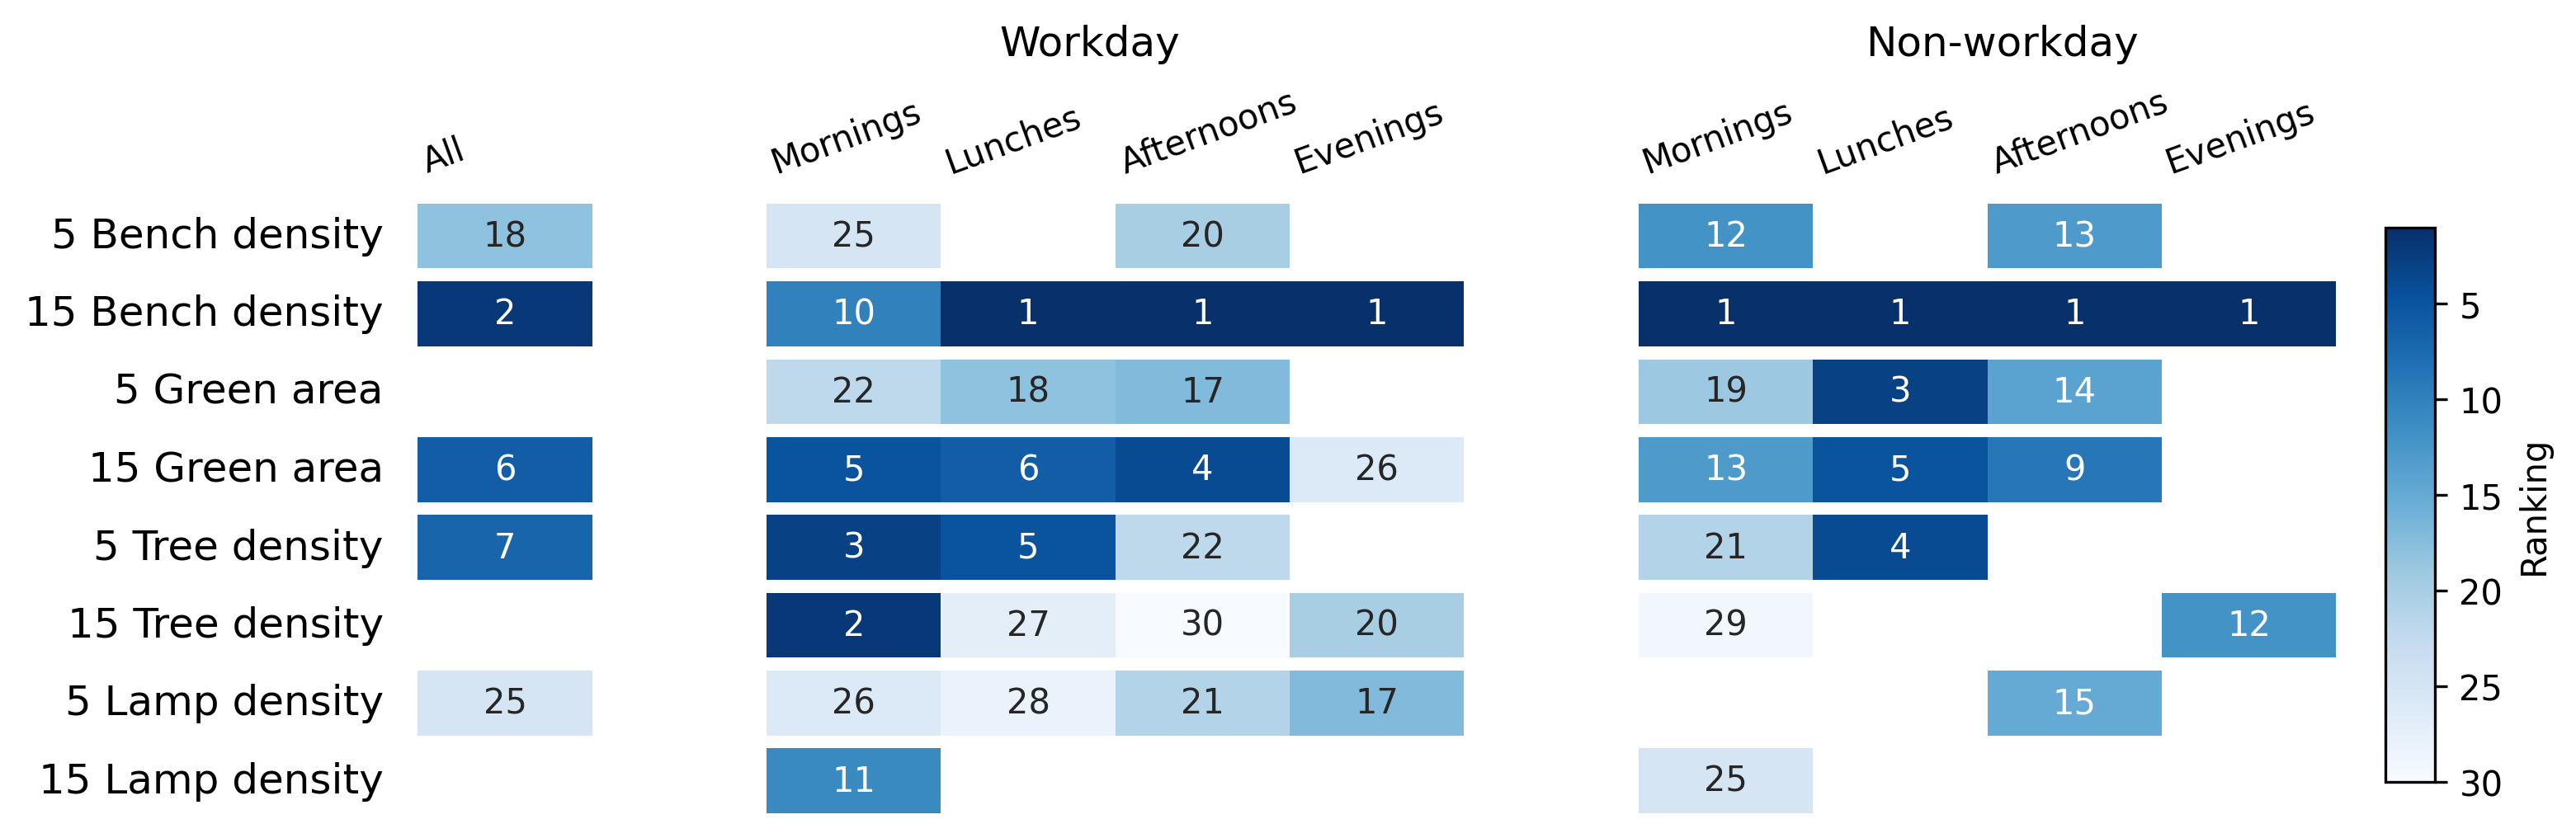

In [ ]:
rankingHeatMapPlot(interested_features=['5 Bench density','15 Bench density','5 Green area','15 Green area',
                                        '5 Tree density','15 Tree density','5 Lamp density','15 Lamp density'], texty=-8,
                                        # fig_name='fig_07_infra_ranking.png'
                                        )

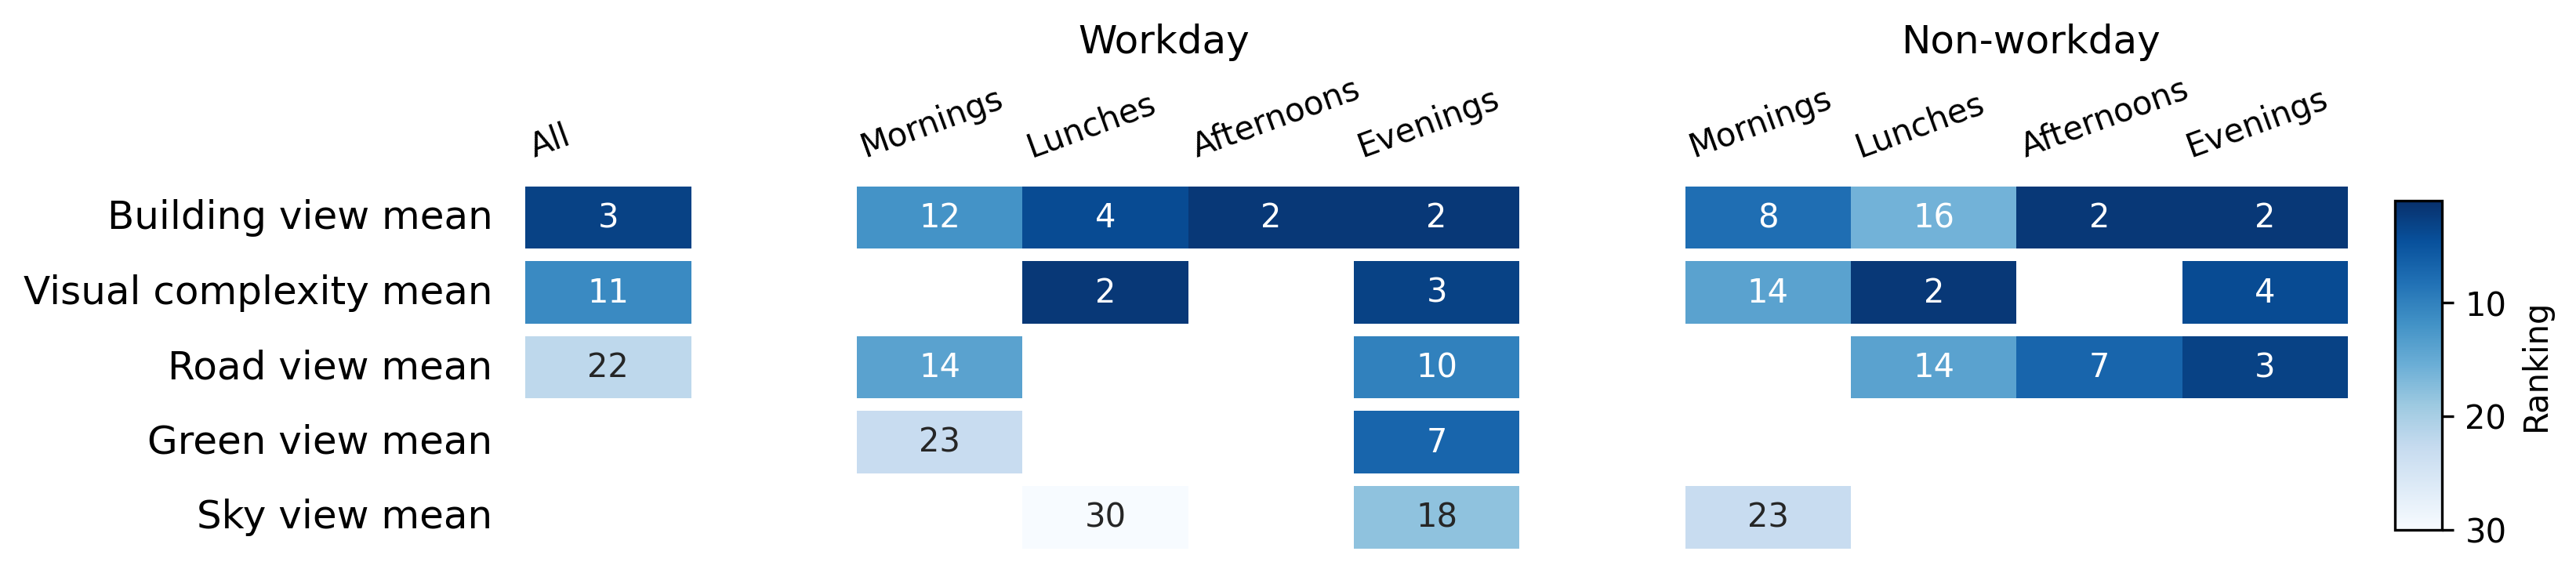

In [ ]:
rankingHeatMapPlot(interested_features = ['Building view mean','Visual complexity mean',
                                          'Road view mean','Green view mean','Sky view mean' ],texty=-12,
                                        #   fig_name= 'fig_09_visual_index_ranking.png'
                                          )

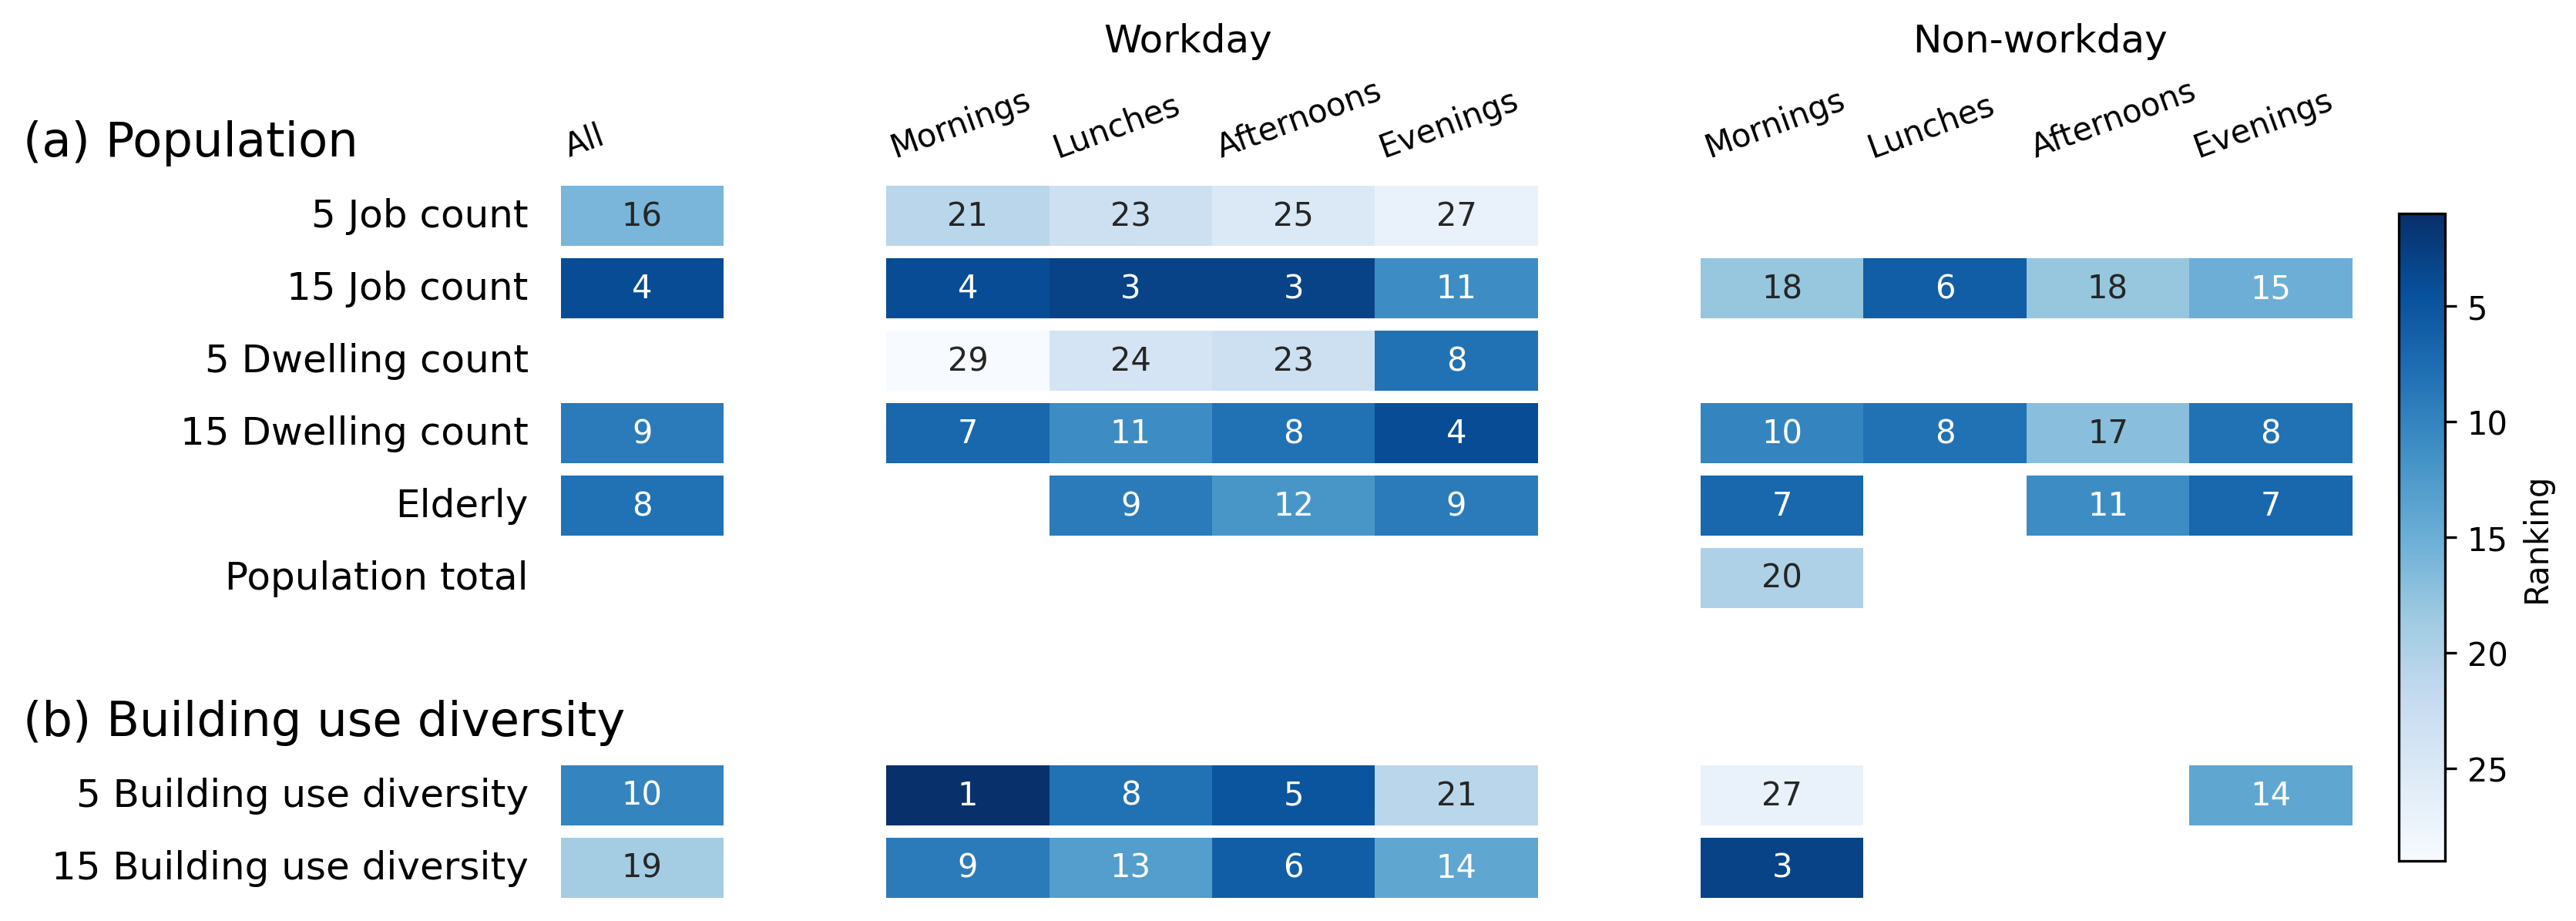

In [ ]:
rankingHeatMapPlot(interested_features = ['5 Job count','15 Job count',
                                          '5 Dwelling count','15 Dwelling count',
                                          'Elderly','Population total',#'Youth',
                                          'GAP', # dummy row
                                          'GAP', # dummy row
                                          '5 Building use diversity','15 Building use diversity'],texty=-6, pop_n_div = True,
                                        #   fig_name = 'fig_11_population_n_diversity_ranking.png'
                                          )

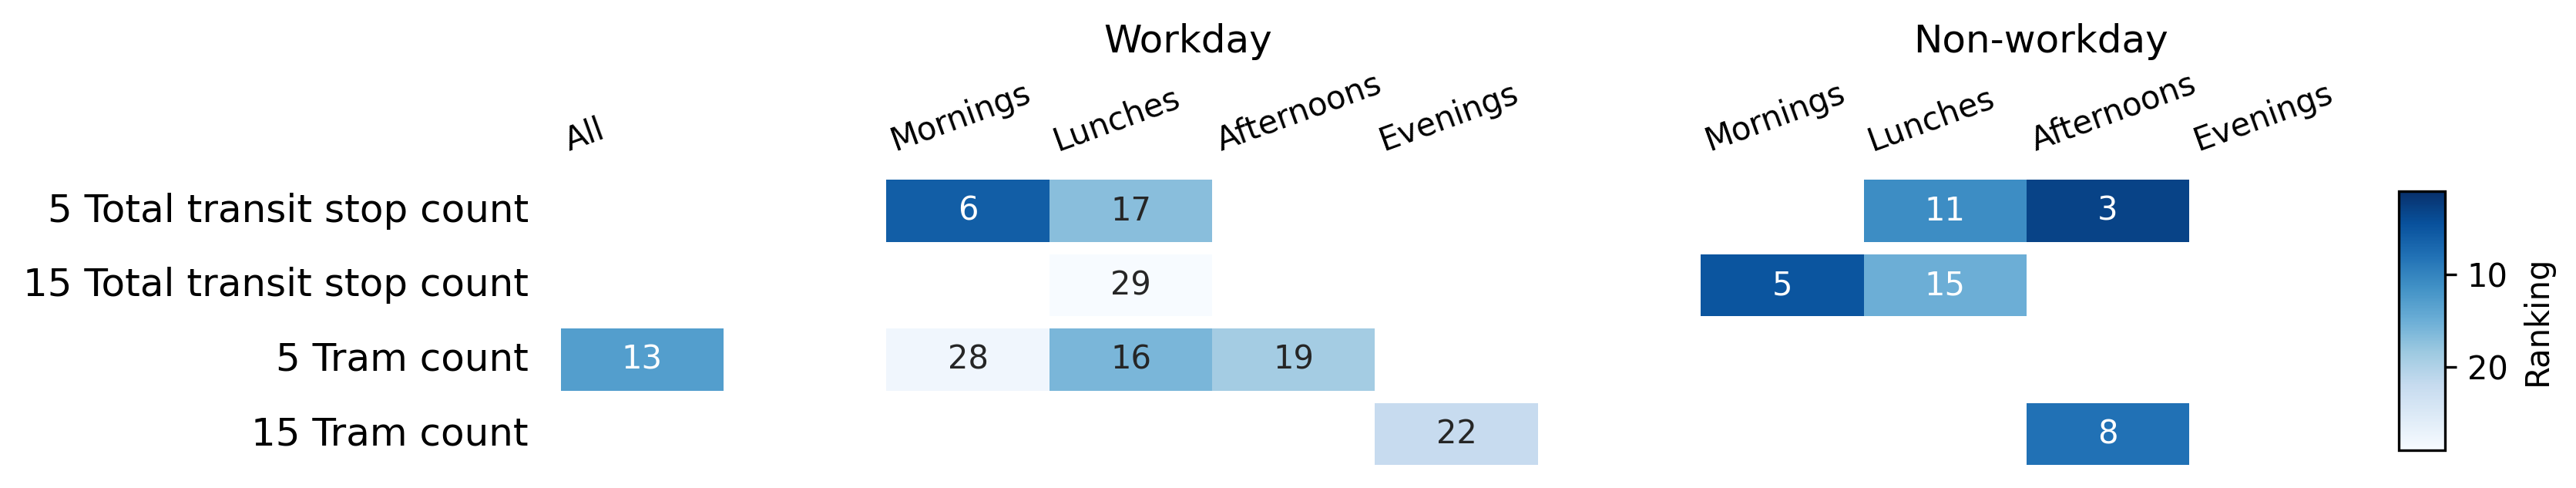

In [52]:
rankingHeatMapPlot(interested_features=['5 Total transit stop count','15 Total transit stop count',
                                        #'5 Bus count','15 Bus count',
                                        '5 Tram count','15 Tram count'],texty=-14,
                                        # fig_name='fig_13_transport_ranking.png'
                                        )

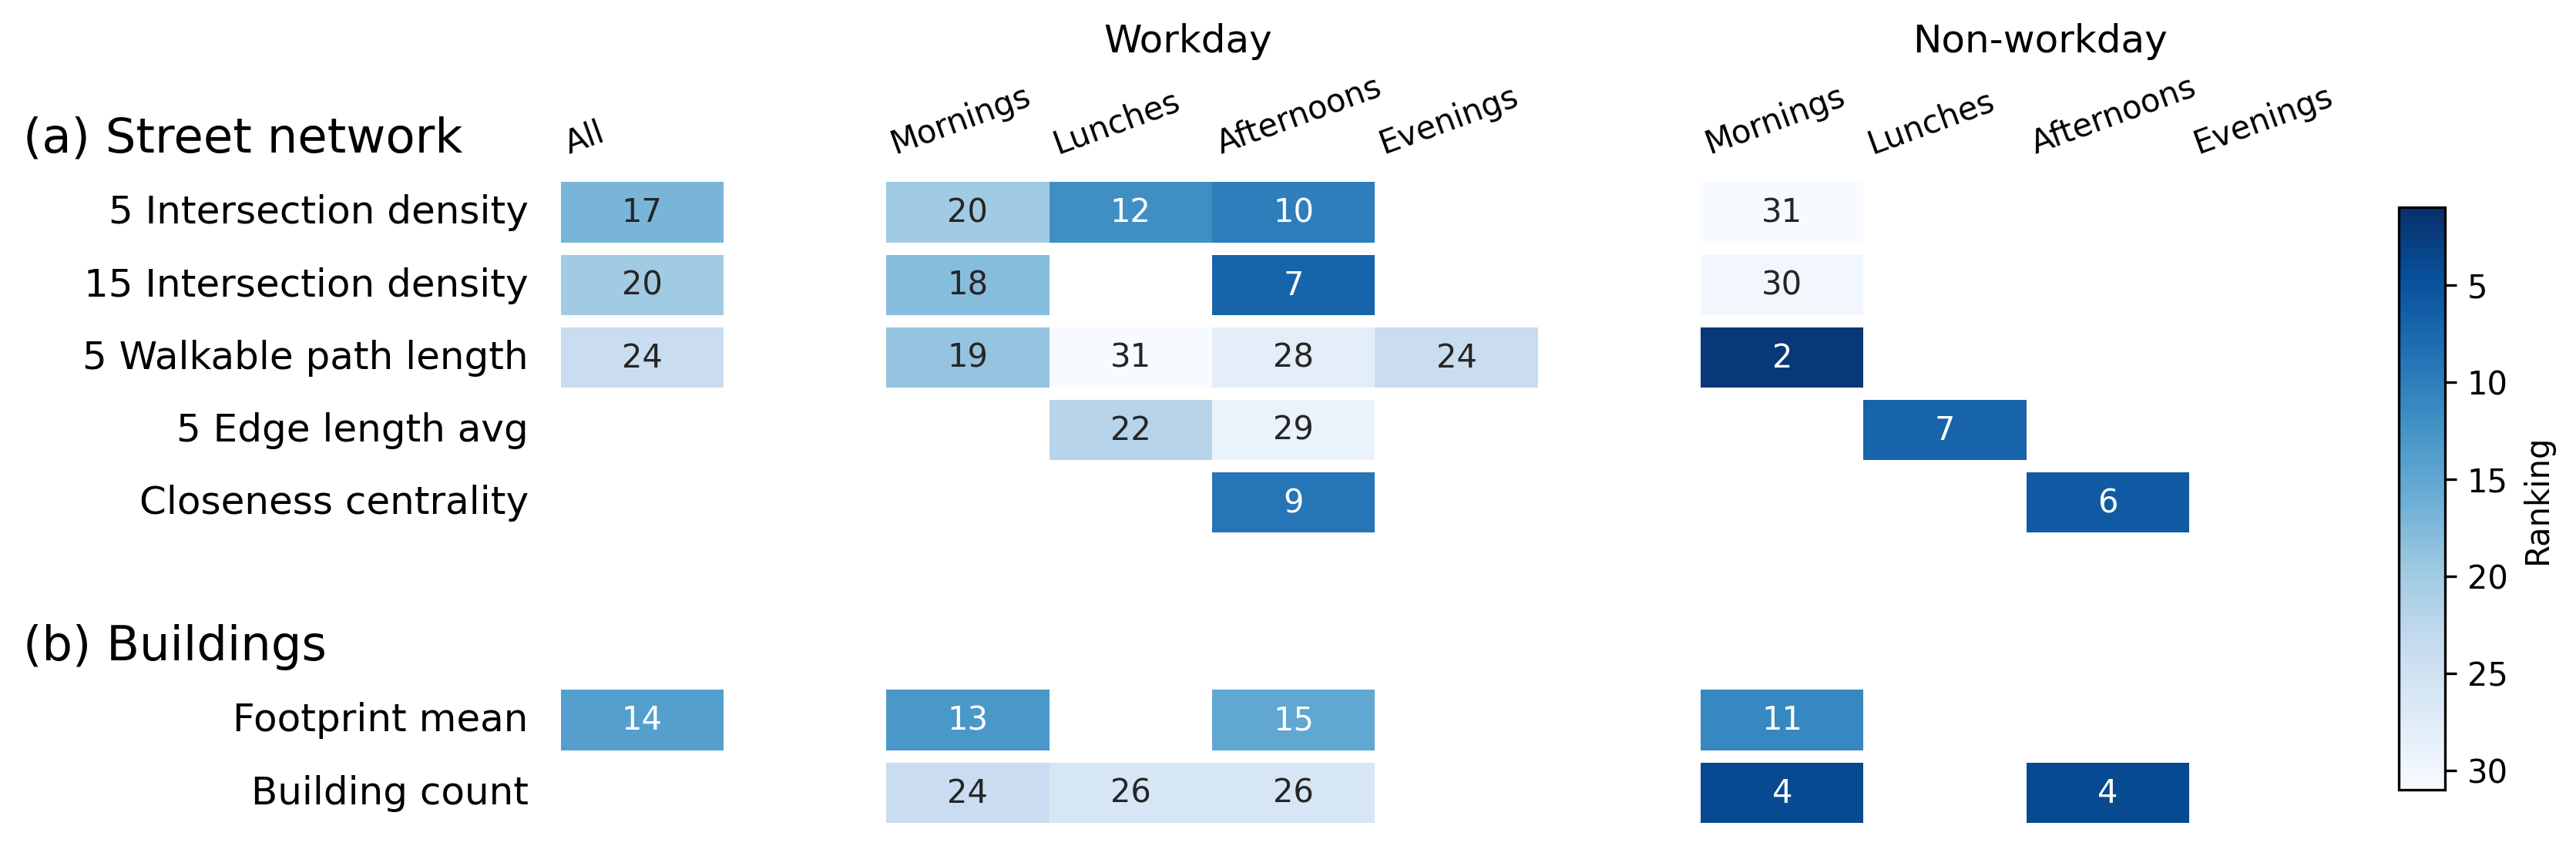

In [ ]:
rankingHeatMapPlot(interested_features=["5 Intersection density","15 Intersection density",
                        "5 Walkable path length", #"15 Walkable path length",
                        "5 Edge length avg","Closeness centrality",
                        "GAP", # dummy row
                        "GAP", # dummy row
                        "Footprint mean", "Building count"
                        ],texty=-7, network_n_bldg = True,
                        # fig_name = 'fig_15_network_n_bldng_ranking.png'
                        )

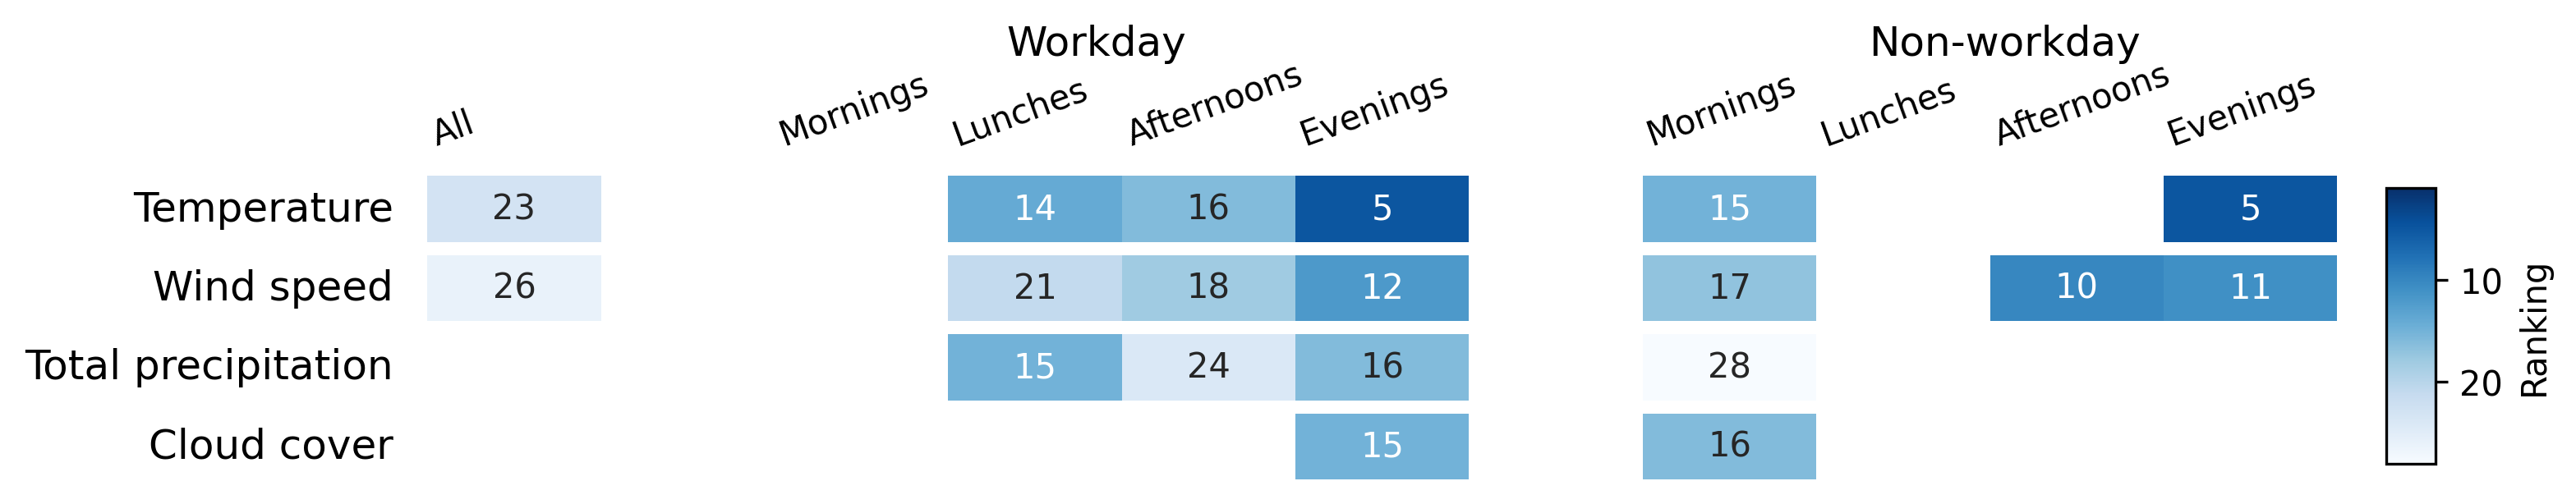

In [54]:
rankingHeatMapPlot(interested_features=['Temperature','Wind speed','Total precipitation','Cloud cover'], texty=-12,
                #    fig_name='fig_17_weather_ranking.png'
                   )

In [55]:
# List of unique dataset names
dataset_names = combined_importance_df_cap['dataset_name'].unique()

# Plot the first dataset as it is
first_dataset_name = dataset_names[0]
df_filtered = combined_importance_df_cap[combined_importance_df_cap['dataset_name'] == first_dataset_name]

df_filtered['sum_importance'] = df_filtered['importance_vals_cat'] + df_filtered['importance_vals_lgbm'] + df_filtered['importance_vals_xgb']
df_filtered = df_filtered.sort_values('sum_importance', ascending=False)
df_filtered_top10 = df_filtered.head(10)

# Calculate number of features not shown
top_10_features = df_filtered_top10['col_name'].values
num_features_not_shown_cat = len(df_filtered[(df_filtered['importance_vals_cat'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])
num_features_not_shown_lgbm = len(df_filtered[(df_filtered['importance_vals_lgbm'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])
num_features_not_shown_xgb = len(df_filtered[(df_filtered['importance_vals_xgb'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])

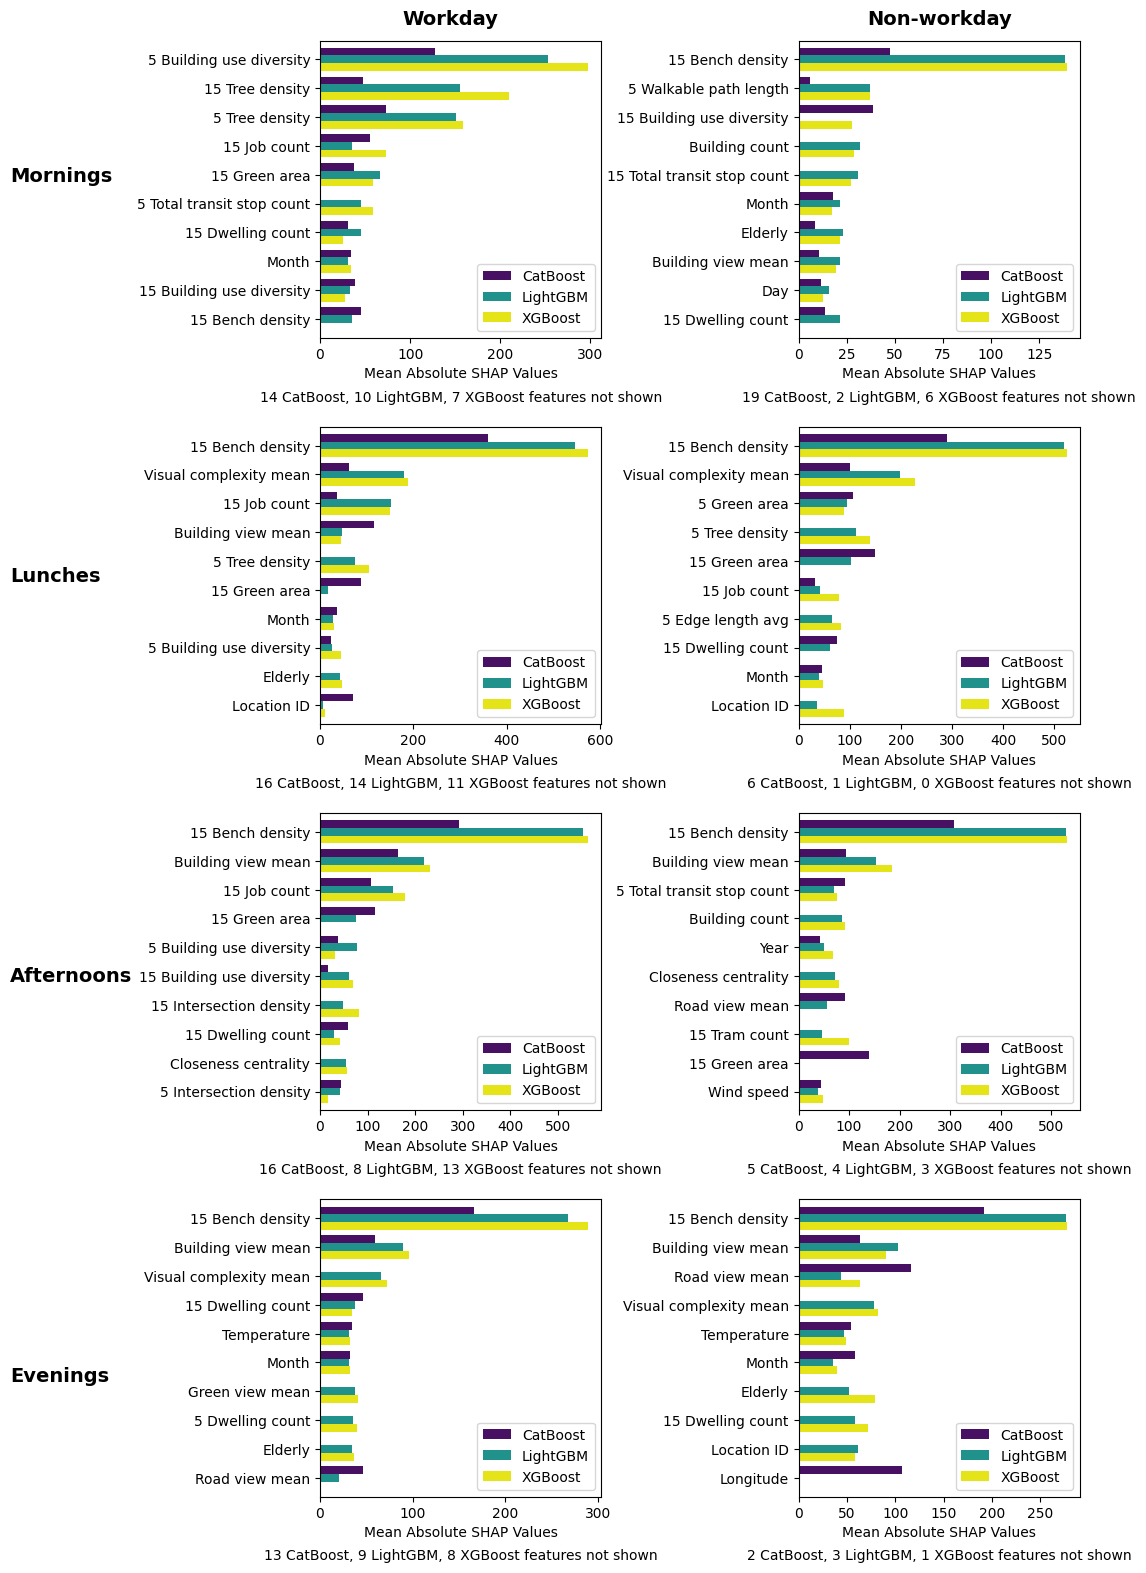

In [ ]:
ordered_dataset_names = [
    "Mornings", "Mornings Special",
    "Lunches", "Lunches Special",
    "Afternoons", "Afternoons Special",
    "Evenings", "Evenings Special"
]
# Define row labels for time periods
row_labels = ["Mornings", "Lunches", "Afternoons", "Evenings"]

# Create a 4x2 grid for the remaining datasets
fig, axes = plt.subplots(4, 2, figsize=(10, 16))  # Adjust figure size
axes = axes.flatten()

for idx, dataset_name in enumerate(ordered_dataset_names):  
    df_filtered = combined_importance_df_cap[combined_importance_df_cap['dataset_name'] == dataset_name]

    df_filtered['sum_importance'] = df_filtered['importance_vals_cat'] + df_filtered['importance_vals_lgbm'] + df_filtered['importance_vals_xgb']
    df_filtered = df_filtered.sort_values('sum_importance', ascending=False)
    df_filtered_top10 = df_filtered.head(10)

    ax = axes[idx]
    df_filtered_top10.plot(
        kind='barh',
        x='col_name',
        y=['importance_vals_cat', 'importance_vals_lgbm', 'importance_vals_xgb'],
        color=plt.cm.viridis([0.04, 0.5, 0.96]),
        ax=ax,
        width=0.8
    )

    # Calculate number of features not shown
    top_10_features = df_filtered_top10['col_name'].values
    num_features_not_shown_cat = len(df_filtered[(df_filtered['importance_vals_cat'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])
    num_features_not_shown_lgbm = len(df_filtered[(df_filtered['importance_vals_lgbm'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])
    num_features_not_shown_xgb = len(df_filtered[(df_filtered['importance_vals_xgb'] > 0) & (~df_filtered['col_name'].isin(top_10_features))])

    # Add text below each subplot
    ax.text(0.5, -0.2,
            f'{num_features_not_shown_cat} CatBoost, {num_features_not_shown_lgbm} LightGBM, {num_features_not_shown_xgb} XGBoost features not shown',
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    ax.set_xlabel('Mean Absolute SHAP Values', fontsize=10)
    ax.set_ylabel(None)
    ax.invert_yaxis()
    ax.legend(['CatBoost', 'LightGBM', 'XGBoost'], fontsize=10)
    ax.set_title("")  # Remove individual subplot titles
    ax.tick_params(axis='y', labelsize=10)

# Add row labels on the leftmost column
for row_idx, label in enumerate(row_labels):
    y_position = 1 - ((row_idx + 0.5) / 4)  # Centered formula for 4 rows
    fig.text(-0.08, y_position, label, fontsize=14, fontweight='bold', ha='left', va='center')#, rotation=90)

# Add Workday and Non-workday labels at the top of columns
fig.text(0.36, 0.97, "Workday", fontsize=14, fontweight='bold', ha='center')
fig.text(0.85, 0.97, "Non-workday", fontsize=14, fontweight='bold', ha='center')

# Adjust layout and spacing
plt.subplots_adjust(hspace=0.3, wspace = 0.7, left=0.23, right=0.99, top=0.96, bottom=0.05)
# plt.savefig(os.path.join(output_dir, 'SM5_SHAP_scores_for_each_dataset.png'), dpi=300, bbox_inches='tight')
plt.show()

In [57]:
ordered_all_features = ['Location ID', 'Longitude', 
                        'Year', 'Month', 'Day', 'Hour', 'Day type',
                        'Temperature', 'Wind speed', 'Total precipitation', 'Cloud cover', 
                        '5 Dwelling count', '15 Dwelling count', '5 Job count', '15 Job count',
                        'Population total', 'Elderly',
                        '5 Building use diversity', '15 Building use diversity', 
                        'Building count', 'Footprint mean', 
                        '5 Walkable path length', '5 Edge length avg', '5 Intersection density', '15 Intersection density', 'Closeness centrality', 
                        '5 Total transit stop count', '15 Total transit stop count','5 Bus count',  '15 Bus count', '5 Tram count', '15 Tram count', 
                        '5 Bench density', '15 Bench density', '5 Tree density', '15 Tree density', '5 Lamp density', '15 Lamp density', 
                        '5 Green area', '15 Green area', 
                        'Building view mean', 'Green view mean', 'Road view mean', 'Sky view mean', 'Visual complexity mean']

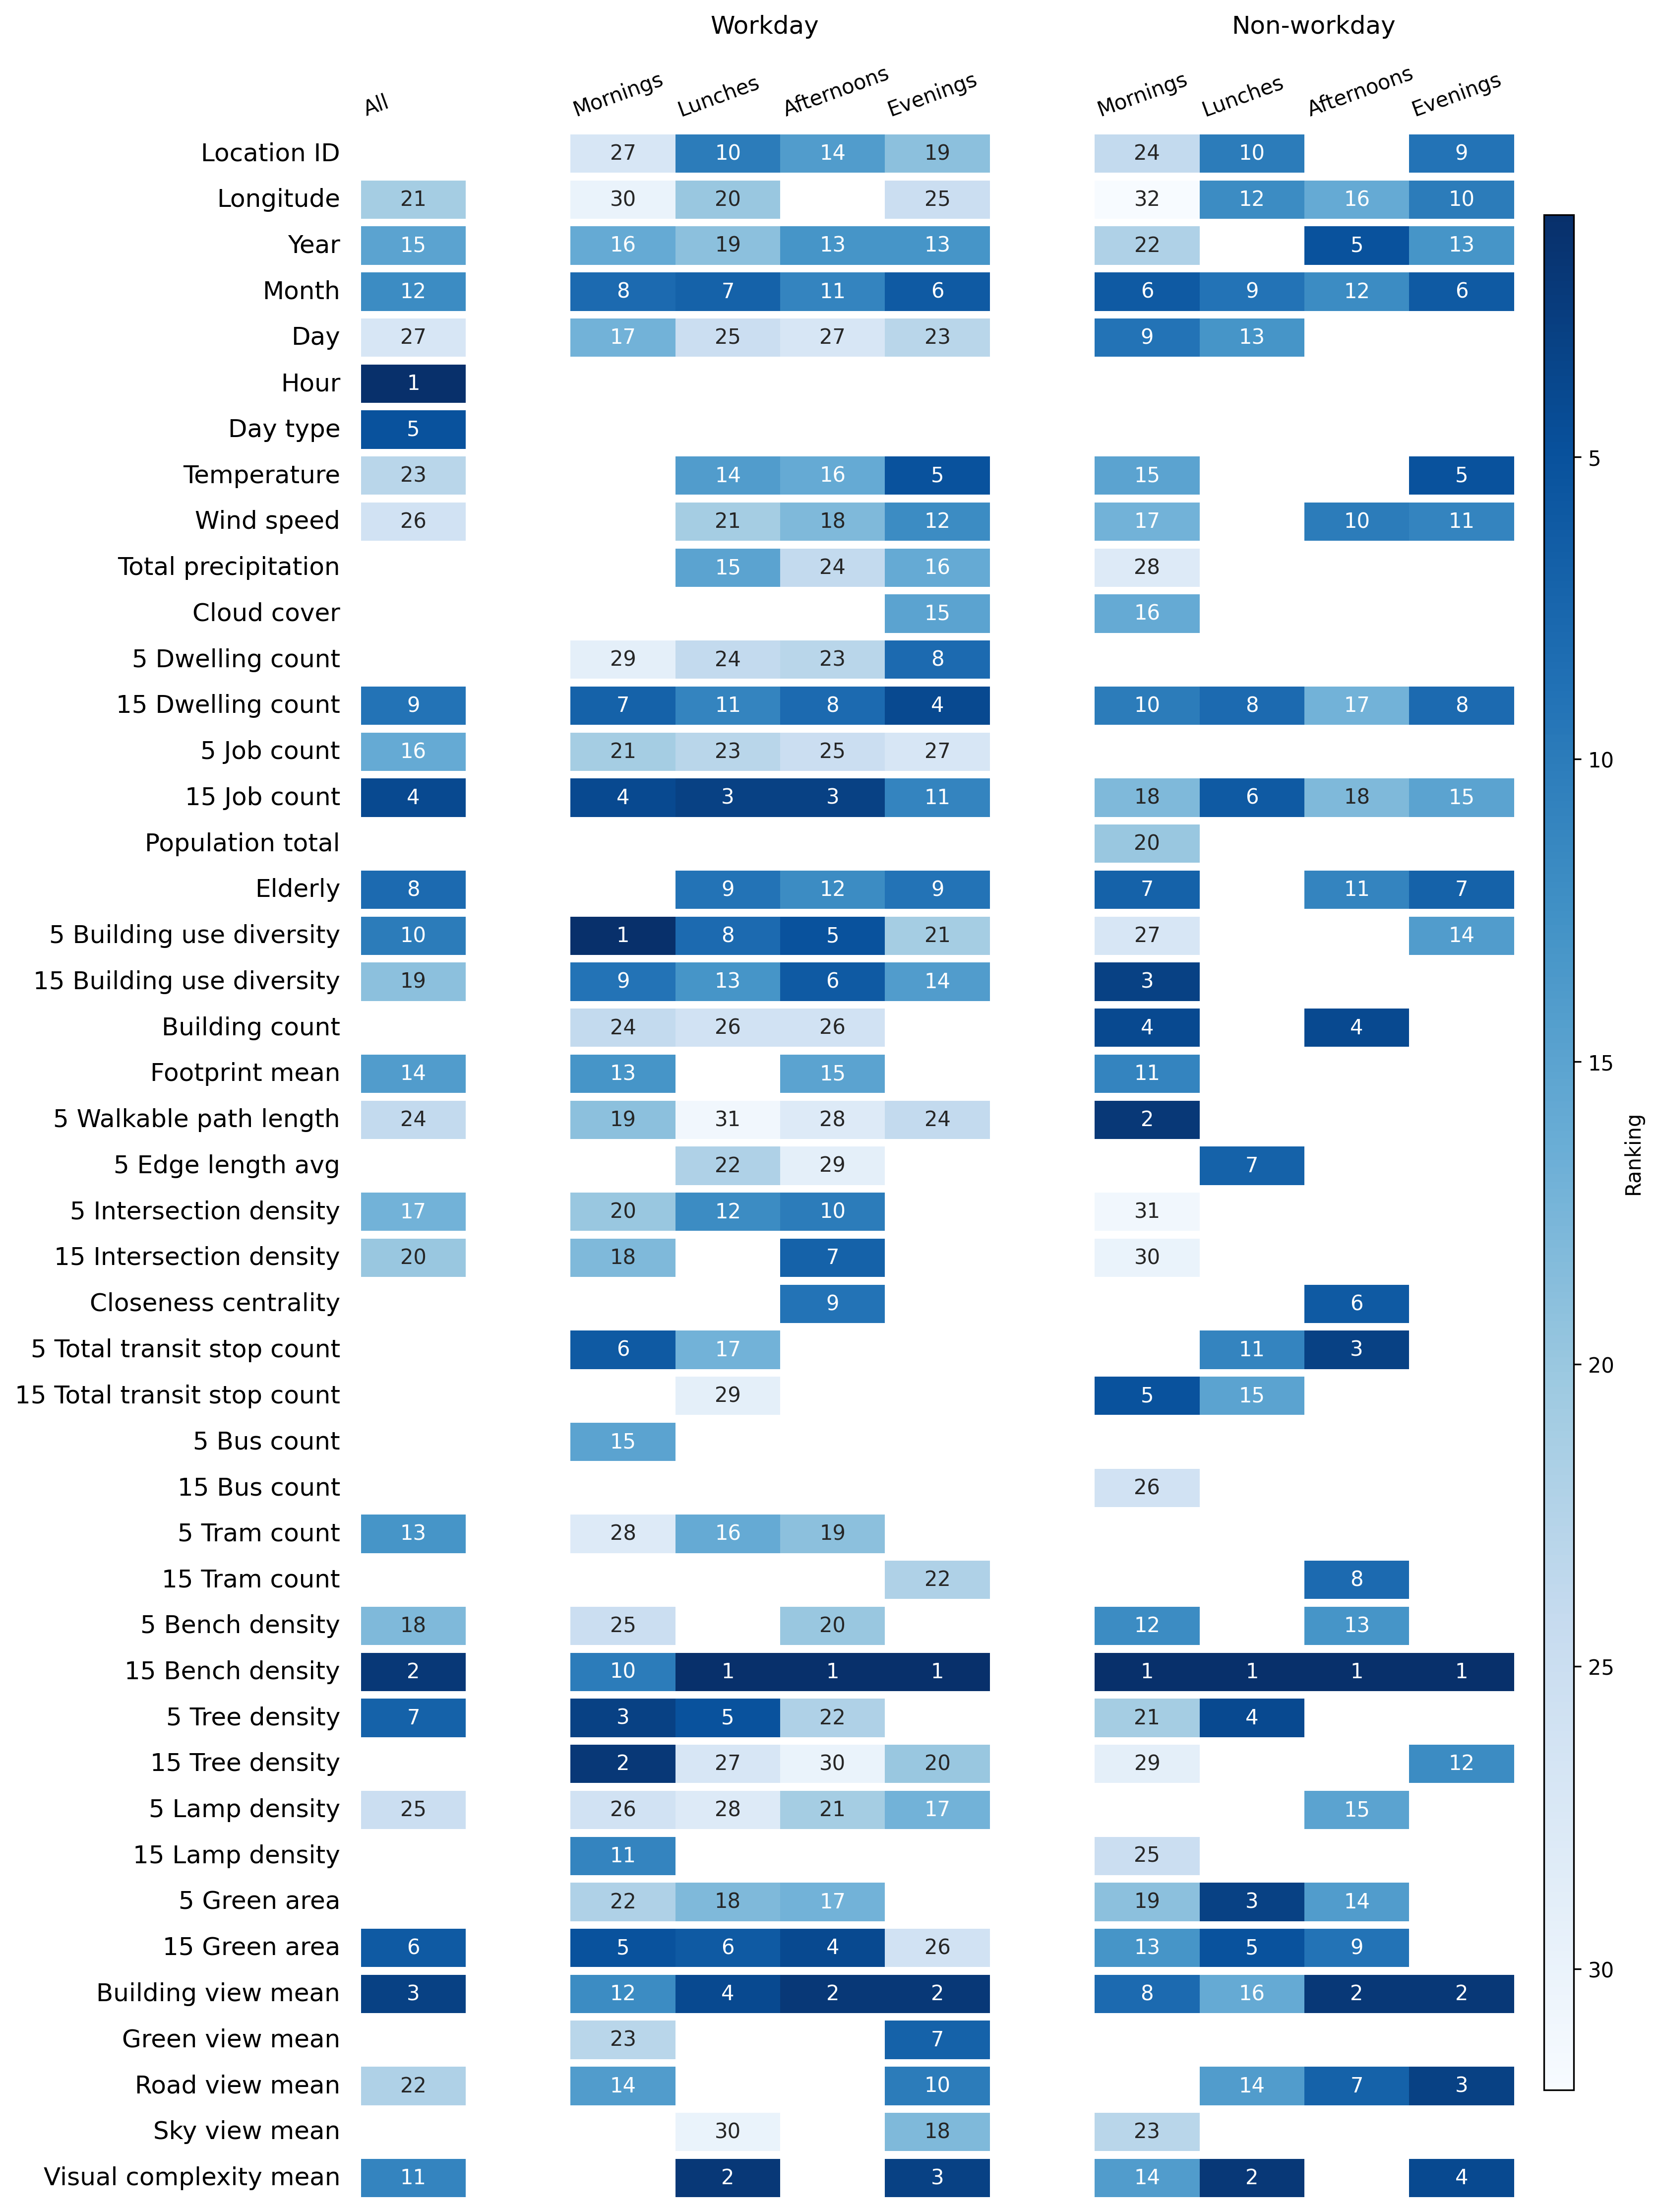

In [ ]:
rankingHeatMapPlot(interested_features =ordered_all_features,texty=-2, int_h=0.4,
                    # fig_name = 'SM6_relative_ranking_all_variables.png'
                    )

## Pedestrian counts

In [59]:
ped_data = processed_melbourne_data[['Year','Month','Day','Day_type','Hour','Location_id','Pedestrian_count']]

In [60]:
# Combine the columns into a single datetime column
ped_data['Time'] = pd.to_datetime(ped_data[['Year', 'Month', 'Day', 'Hour']])

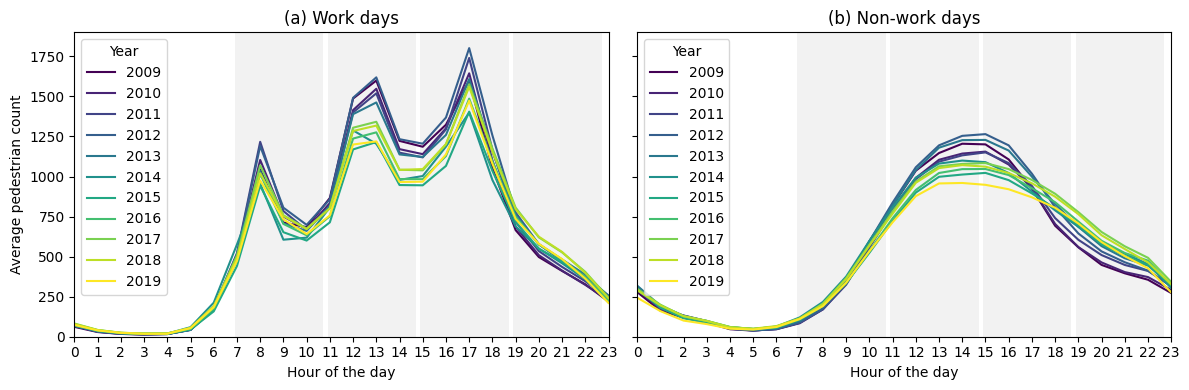

In [61]:
ymax=1900
winterval=3.8
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)  # Create two subplots side by side

for ax, daytype, title in zip(axes, [0, 1], ['(a) Work days', '(b) Non-work days']):
    filtered_data = ped_data[ped_data['Day_type'] == daytype]
    hourly_avg = filtered_data.groupby(['Year', 'Hour'])['Pedestrian_count'].mean().reset_index()
    hourly_avg_pivot = hourly_avg.pivot_table(index='Hour', columns='Year', values='Pedestrian_count')

    num_years = len(hourly_avg_pivot.columns)
    viridis = plt.get_cmap('viridis')
    color_indices = np.linspace(0, 1, num_years)
    colors = [viridis(i) for i in color_indices]

    for idx, year in enumerate(hourly_avg_pivot.columns):
        ax.plot(hourly_avg_pivot.index, hourly_avg_pivot[year], label=f'{year}', color=colors[idx])

    for x in [6.9, 10.9, 14.9, 18.9]:  # Adding shaded rectangles
        rect = patches.Rectangle((x, 0), winterval, ymax, facecolor='grey', alpha=0.1)
        ax.add_patch(rect)

    ax.set_xlabel('Hour of the day')
    ax.set_title(title)
    ax.set_xticks(range(0, 24))
    ax.set_xticklabels([f'{i}' for i in range(24)])
    ax.set_xlim(0, 23)
    ax.set_ylim(0, ymax)

axes[0].set_ylabel('Average pedestrian count')
axes[0].legend(title='Year')
axes[1].legend(title='Year')#, loc='upper right')

plt.tight_layout()  # Adjust layout for better spacing
# plt.savefig(os.path.join(output_dir, 'fig_06_pedestrian_count.png'), dpi=1000, bbox_inches='tight')
plt.show()